# 84/84 Base+Public Holdout | V14 Clone Preemption

### Kaggriculture Competition Notebook

V14 is a complete, directly runnable Kaggriculture agent. It is not a clean-room implementation. Its 719-turn production schedule is reconstructed from public Gold-tier replays; Market-order ranking and actor-local `WEED` recovery reuse and adapt public V23 research; and near-clone preemption inherits the shift/repay controller from V13-R3. New replay clustering, action-by-action route recovery, parameter selection, and blind evaluation complete this release.

Local paired-seat records:

- Base reproduction vs six historical public strong agents: **96–0**
- V14 vs the base reproduction and six public agents: **84–0**
- V14 vs Ueddy replay proxies: **48–0**
- V14 vs CemBas replay proxies: **48–0**
- V14 vs Seb replay proxies: **4–44**
- V14 vs wangtf96: **4–8**

This notebook recomputes every displayed record and reconstructs the exact `main.py` and `submission.tar.gz` artifacts at the end.

In [1]:
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version as package_version

_EXPECTED_ENGINE_VERSION = '1.32.6'
try:
    _installed_engine_version = package_version("kaggle-environments")
except PackageNotFoundError:
    _installed_engine_version = None

if _installed_engine_version != _EXPECTED_ENGINE_VERSION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--disable-pip-version-check",
            "--no-deps",
            f"kaggle-environments=={_EXPECTED_ENGINE_VERSION}",
        ],
        check=True,
    )
    _installed_engine_version = package_version("kaggle-environments")

assert _installed_engine_version == _EXPECTED_ENGINE_VERSION
print(f"Using kaggle-environments=={_installed_engine_version}.")

from collections import defaultdict
from io import StringIO
import csv
import json

try:
    from IPython.display import display, Markdown
except ImportError:
    class Markdown(str):
        pass
    def display(value):
        print(str(value))

try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

AGENT_SHA256 = 'a7f827b9438885b34b7fd5bf8165458a72f8bb83031a288dd4640f21ade3294b'
ARCHIVE_SHA256 = '47ab26c4ee09eeddcefd5df1de26fb23345a687659c5a94260b7845d21a0aa01'
ENGINE_COMMIT = 'bded87b0d7879078c726a93a4884d044f79c4eed'
ENGINE_VERSION = '1.32.6'

games = list(csv.DictReader(StringIO(r"""panel,target,seed,seat,margin,result,invalid,timeout,unsold
Reproduction vs historical public strong agents,kaito_v23,101,0,2952.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,101,1,2952.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,211,0,2997.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,211,1,2997.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,307,0,2131.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,307,1,2131.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,401,0,2746.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,401,1,2746.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,503,0,2978.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,503,1,2978.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,601,0,2237.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,601,1,2237.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,701,0,2139.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,701,1,2139.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,809,0,3014.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v23,809,1,3014.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,101,0,6498.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,101,1,6498.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,211,0,6268.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,211,1,6268.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,307,0,5295.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,307,1,5295.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,401,0,2248.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,401,1,2248.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,503,0,5192.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,503,1,5192.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,601,0,4895.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,601,1,4895.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,701,0,4997.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,701,1,10071.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,809,0,639.0,win,0,0,0
Reproduction vs historical public strong agents,kaito_v22,809,1,639.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,101,1,6498.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,101,0,6498.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,211,1,6268.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,211,0,6268.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,307,1,5295.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,307,0,5295.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,401,1,2248.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,401,0,2248.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,503,1,5192.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,503,0,5192.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,601,1,4857.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,601,0,4857.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,701,1,9824.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,701,0,4997.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,809,1,639.0,win,0,0,0
Reproduction vs historical public strong agents,andrew_v22_terminal,809,0,639.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,101,0,11055.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,101,1,11055.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,211,0,9715.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,211,1,10408.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,307,0,9715.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,307,1,9715.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,401,0,7756.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,401,1,7660.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,503,0,10408.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,503,1,10408.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,601,0,9129.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,601,1,9129.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,701,0,8943.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,701,1,9788.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,809,0,9432.0,win,0,0,0
Reproduction vs historical public strong agents,v13_r3,809,1,9432.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,101,0,11659.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,101,1,11659.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,211,0,11293.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,211,1,11293.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,307,0,10541.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,307,1,10541.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,401,0,7327.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,401,1,7327.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,503,0,10562.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,503,1,10562.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,601,0,8687.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,601,1,8687.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,701,0,8441.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,701,1,9260.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,809,0,9892.0,win,0,0,0
Reproduction vs historical public strong agents,rayk_v21_impact,809,1,9892.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,101,0,7873.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,101,1,7873.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,211,0,6375.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,211,1,6375.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,307,0,4296.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,307,1,4296.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,401,0,6835.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,401,1,6835.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,503,0,7898.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,503,1,7898.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,601,0,6288.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,601,1,6288.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,701,0,5059.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,701,1,5059.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,809,0,5064.0,win,0,0,0
Reproduction vs historical public strong agents,indar_verified,809,1,5064.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,2707,1,5140.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,2707,0,5140.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,2801,1,4202.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,2801,0,4202.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,2903,1,2090.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,2903,0,2090.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,3001,1,4706.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,3001,0,4706.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,3109,1,2553.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,3109,0,2553.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,3203,1,4810.0,win,0,0,0
V14 vs base reproduction and public agents,andrew_v22_terminal,3203,0,4810.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,2707,0,563.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,2707,1,563.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,2801,0,825.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,2801,1,825.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,2903,0,2184.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,2903,1,2184.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,3001,0,2210.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,3001,1,2210.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,3109,0,3586.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,3109,1,3586.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,3203,0,3179.0,win,0,0,0
V14 vs base reproduction and public agents,frontier_v1,3203,1,3179.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,2707,0,6814.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,2707,1,6814.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,2801,0,6398.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,2801,1,6398.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,2903,0,9735.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,2903,1,9735.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,3001,0,7867.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,3001,1,7867.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,3109,0,6477.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,3109,1,6477.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,3203,0,5923.0,win,0,0,0
V14 vs base reproduction and public agents,indar_verified,3203,1,5923.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,2707,0,5140.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,2707,1,5140.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,2801,0,4202.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,2801,1,4202.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,2903,0,2090.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,2903,1,2090.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,3001,0,4706.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,3001,1,4706.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,3109,0,2553.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,3109,1,2553.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,3203,0,4810.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v22,3203,1,4810.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,2707,0,2661.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,2707,1,2661.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,2801,0,3880.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,2801,1,3880.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,2903,0,6296.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,2903,1,6296.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,3001,0,4255.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,3001,1,4255.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,3109,0,3715.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,3109,1,3715.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,3203,0,3883.0,win,0,0,0
V14 vs base reproduction and public agents,kaito_v23,3203,1,3883.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,2707,0,9982.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,2707,1,9982.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,2801,0,9028.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,2801,1,9028.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,2903,0,11381.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,2903,1,11381.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,3001,0,9174.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,3001,1,9174.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,3109,0,8285.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,3109,1,8285.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,3203,0,9957.0,win,0,0,0
V14 vs base reproduction and public agents,rayk_v21_impact,3203,1,9957.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,2707,0,9063.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,2707,1,9063.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,2801,0,8195.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,2801,1,8195.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,2903,0,10207.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,2903,1,10207.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,3001,0,9236.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,3001,1,9126.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,3109,0,7972.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,3109,1,7972.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,3203,0,9830.0,win,0,0,0
V14 vs base reproduction and public agents,v13_r3,3203,1,9830.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,2707,0,3225.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,2707,1,3225.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,2801,0,3638.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,2801,1,3638.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,2903,0,6181.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,2903,1,6181.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,3001,0,3811.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,3001,1,3811.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,3109,0,4031.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,3109,1,4031.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,3203,0,3917.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90897351_s1,3203,1,3917.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,2707,0,4283.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,2707,1,4283.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,2801,0,3745.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,2801,1,3745.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,2903,0,6104.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,2903,1,6104.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,3001,0,3840.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,3001,1,3840.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,3109,0,5460.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,3109,1,5460.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,3203,0,4502.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90899851_s0,3203,1,4502.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,2707,0,5802.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,2707,1,5802.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,2801,0,4588.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,2801,1,4588.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,2903,0,7271.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,2903,1,7271.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,3001,0,4109.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,3001,1,4109.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,3109,0,5575.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,3109,1,5575.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,3203,0,4506.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90900709_s0,3203,1,4506.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,2707,0,3440.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,2707,1,3440.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,2801,0,3207.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,2801,1,3207.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,2903,0,5495.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,2903,1,5495.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,3001,0,3644.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,3001,1,3644.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,3109,0,4531.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,3109,1,4531.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,3203,0,3384.0,win,0,0,0
V14 vs untouched Ueddy replay proxies,ueddy_holdout_90916074_s1,3203,1,3384.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3301,1,2200.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3301,0,2200.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3407,1,1400.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3407,0,1400.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3511,1,4572.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3511,0,4572.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3607,1,2556.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3607,0,2556.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3701,1,3061.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3701,0,3061.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3803,1,1778.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90915110_s1,3803,0,1778.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3301,1,2556.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3301,0,2556.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3407,1,1599.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3407,0,1599.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3511,1,5234.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3511,0,5234.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3607,1,2242.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3607,0,2242.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3701,1,2512.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3701,0,2512.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3803,1,1877.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90918455_s0,3803,0,1877.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3301,1,2817.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3301,0,2817.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3407,1,1277.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3407,0,1277.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3511,1,5218.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3511,0,5218.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3607,1,2861.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3607,0,2861.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3701,1,3306.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3701,0,3306.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3803,1,1759.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919309_s0,3803,0,1759.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3301,1,2693.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3301,0,2693.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3407,1,1158.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3407,0,1158.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3511,1,5171.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3511,0,5171.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3607,1,2819.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3607,0,2819.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3701,1,3371.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3701,0,3371.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3803,1,1826.0,win,0,0,0
V14 vs later-sampled current CemBas replay proxies,cem_current_90919334_s1,3803,0,1826.0,win,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,2707,0,-10584.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,2707,1,-10584.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,2801,0,-32486.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,2801,1,-32486.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,2903,0,-9340.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,2903,1,-9340.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,3001,0,-34365.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,3001,1,-30175.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,3109,0,-4864.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,3109,1,-4462.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,3203,0,-32596.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90851845_s1,3203,1,-33949.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,2707,0,9703.0,win,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,2707,1,9703.0,win,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,2801,0,11814.0,win,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,2801,1,11814.0,win,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,2903,0,-5434.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,2903,1,-5434.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,3001,0,-25291.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,3001,1,-23484.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,3109,0,-14242.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,3109,1,-14242.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,3203,0,-7075.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90893264_s0,3203,1,-8156.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,2707,0,-25056.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,2707,1,-25056.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,2801,0,-45405.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,2801,1,-45405.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,2903,0,-23112.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,2903,1,-23112.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,3001,0,-45656.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,3001,1,-45197.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,3109,0,-1367.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,3109,1,-810.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,3203,0,-51651.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90914286_s0,3203,1,-51651.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,2707,0,-11824.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,2707,1,-11824.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,2801,0,-1118.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,2801,1,-1118.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,2903,0,-46070.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,2903,1,-46070.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,3001,0,-45229.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,3001,1,-40532.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,3109,0,-22758.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,3109,1,-22758.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,3203,0,-29295.0,loss,0,0,0
V14 vs Seb alternate-route replay proxies,seb_holdout_90915190_s1,3203,1,-28820.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,2707,0,-52337.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,2707,1,-52337.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,2801,0,-46960.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,2801,1,-46960.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,2903,0,2033.0,win,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,2903,1,2033.0,win,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,3001,0,36691.0,win,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,3001,1,26194.0,win,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,3109,0,-17136.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,3109,1,-14819.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,3203,0,-1619.0,loss,0,0,0
V14 vs wangtf96 alternate strategy,wangtf96,3203,1,-1619.0,loss,0,0,0""")))
dev_rows = json.loads(r"""[{"variant":"exact_p50_b12","games":12,"wins":12,"losses":0,"mean_margin":1548.3,"worst_margin":498.0,"paired_positive":6},{"variant":"near_p100_b24","games":12,"wins":12,"losses":0,"mean_margin":2368.3,"worst_margin":797.0,"paired_positive":6},{"variant":"near_p200_b30","games":12,"wins":12,"losses":0,"mean_margin":2447.0,"worst_margin":804.0,"paired_positive":6},{"variant":"near_p50_b12","games":12,"wins":12,"losses":0,"mean_margin":1640.3,"worst_margin":498.0,"paired_positive":6},{"variant":"near_price50","games":12,"wins":12,"losses":0,"mean_margin":1842.0,"worst_margin":277.0,"paired_positive":6}]""")

for row in games:
    row["seed"] = int(row["seed"])
    row["seat"] = int(row["seat"])
    row["margin"] = float(row["margin"])
    for key in ("invalid", "timeout", "unsold"):
        row[key] = int(row[key])

def markdown_table(rows, columns=None):
    rows = list(rows)
    if not rows:
        return "_No data._"
    columns = columns or list(rows[0])
    header = "| " + " | ".join(columns) + " |"
    rule = "|" + "|".join("---" for _ in columns) + "|"
    body = ["| " + " | ".join(str(row.get(column, "")) for column in columns) + " |" for row in rows]
    return "\n".join([header, rule, *body])

def summarize(rows, key="panel"):
    grouped = defaultdict(list)
    for row in rows:
        grouped[row[key]].append(row)
    output = []
    for name, panel_rows in grouped.items():
        output.append({
            key: name,
            "games": len(panel_rows),
            "W-D-L": f"{sum(r['result']=='win' for r in panel_rows)}-{sum(r['result']=='draw' for r in panel_rows)}-{sum(r['result']=='loss' for r in panel_rows)}",
        })
    return output

assert len(games) == 336
assert sum(row["invalid"] + row["timeout"] + row["unsold"] for row in games) == 0
print(f"Loaded {len(games)} evaluation games.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.6 MB/s eta 0:00:00
Using kaggle-environments==1.32.6.
Loaded 336 evaluation games.


## 1. From V13-R3 to V14: The Frontier Moved Again

V13-R3 established a key result: once high-score production schedules converge, action order in the shared Market can matter more than marginal production. Later public replays show the frontier evolving into two closely related V23/Kakuteki variants:

| Dimension | V13-R3 | V14 |
|---|---|---|
| Production schedule | Earlier replay-derived Gold-tier core | Updated Kakuteki / mrgrishninsb route |
| Market layer | Static hazard prior + shift/repay | Nonlinear price-impact ranking + dynamic next-turn shift/repay |
| Endgame | Final-turn liquidation | Dynamic Shed-aware liquidation from step 716 |
| Activation scope | Near clones; four premium products | Near clones; four premium products; at most 30 units per shift |

The updated Kakuteki route differs from the older V23 variant in only a small number of field and farm-hand actions. V14 adds dynamic endgame liquidation and next-turn `SELL` preemption to this production backbone.

## 2. Complete V14 Architecture and Activation Gates

Preemption is a bounded overlay on a complete agent, not a Market-only script detached from production.

| Layer | Runtime responsibility |
|---|---|
| 719-turn production schedule | Executes the full farm-hand, land, crop, animal, and baseline Market plan |
| Farm-hand alignment | Pads or truncates actions to match the current public `hands` list |
| Actor-local `WEED` recovery | If a random weed blocks `PLANT` or `BUILD_PASTURE`, the affected actor runs `DIG`, retries, and performs a bounded catch-up |
| V23 price-impact ranking | Reorders baseline `SELL` slots using current shared Market inventory, the nonlinear price function, and Town demand |
| Near-clone gate | Compares both farms' public `hands`, `unlocked_quadrants`, and tile structures; clone distance must be at most 6 |
| Next-turn `SELL` preemption | Covers only `STRAWBERRY`, `MELON`, `MILK`, and `WOOL`, and only while `120 <= step < 680` |
| Quantity bounds | Constrained by the next-turn planned quantity, projected own Shed inventory, a 30-unit cap, and the 10-order Market limit |
| Repayment | Deducts the shifted quantity from the same product's baseline `SELL` on the next turn |
| Dynamic endgame liquidation | From step 716, appends orders from the live Shed state so unsold inventory is not stranded at season end |

V14 does not use the opponent's private state and does not read replays at runtime. Every decision uses only the current observation's public state and its own private inventory.

In [2]:
display(Markdown("### Development-Set Parameter Sweep\n" + markdown_table(dev_rows)))

selected = next(row for row in dev_rows if row["variant"] == "near_p200_b30")
assert selected["wins"] == 12 and selected["losses"] == 0 and selected["paired_positive"] == 6

gates = [
    {"Parameter": "clone distance", "V14": "<= 6"},
    {"Parameter": "active steps", "V14": "120–679"},
    {"Parameter": "premium products", "V14": "STRAWBERRY / MELON / MILK / WOOL"},
    {"Parameter": "minimum next-turn SELL", "V14": ">= 4"},
    {"Parameter": "maximum shift per product", "V14": "30"},
    {"Parameter": "selected variant", "V14": "near_p200_b30"},
]
display(Markdown("### Final Activation Gates\n" + markdown_table(gates)))

### Development-Set Parameter Sweep
| variant | games | wins | losses | mean_margin | worst_margin | paired_positive |
|---|---|---|---|---|---|---|
| exact_p50_b12 | 12 | 12 | 0 | 1548.3 | 498.0 | 6 |
| near_p100_b24 | 12 | 12 | 0 | 2368.3 | 797.0 | 6 |
| near_p200_b30 | 12 | 12 | 0 | 2447.0 | 804.0 | 6 |
| near_p50_b12 | 12 | 12 | 0 | 1640.3 | 498.0 | 6 |
| near_price50 | 12 | 12 | 0 | 1842.0 | 277.0 | 6 |

### Final Activation Gates
| Parameter | V14 |
|---|---|
| clone distance | <= 6 |
| active steps | 120–679 |
| premium products | STRAWBERRY / MELON / MILK / WOOL |
| minimum next-turn SELL | >= 4 |
| maximum shift per product | 30 |
| selected variant | near_p200_b30 |

## 3. Why V14 Remains Order-Safe

V14 aims to move ahead of an opponent's large premium `SELL` on the **next turn**. It does not jump ahead of its own valuable Market orders on the **current turn**.

The execution order is:

1. Generate and repair the baseline action.
2. Repay quantities shifted on the previous turn.
3. Rank the existing `SELL` slots with the V23 price-impact scorer.
4. If the near-clone gate passes, append the new preemption order to a remaining Market slot.
5. Deduct the same quantity from the next turn's baseline `SELL` tape.

The planned two-turn quantity is therefore conserved:

| Strategy | Turn `t` | Turn `t+1` | Planned two-turn quantity |
|---|---:|---:|---:|
| Base reproduction | — | `SELL item q` | `q` |
| V14 | `SELL item s` | `SELL item (q-s)` | `s + (q-s) = q` |

This is a tightly scoped timing controller, not a general opponent-prediction model.

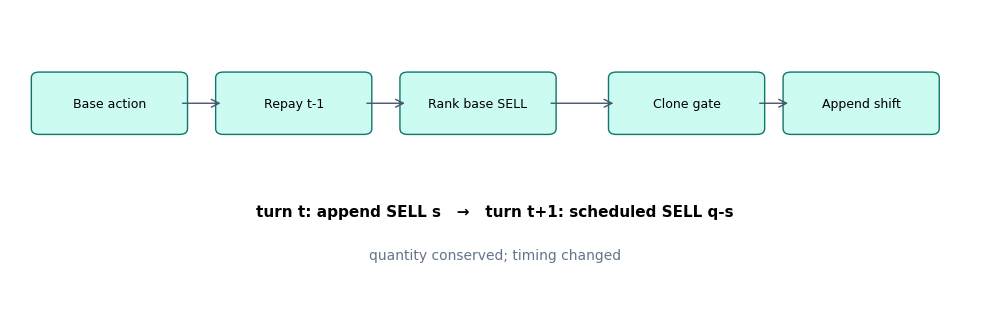

In [3]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis("off")
    boxes = [
        (0.3, 2.35, "Base action"),
        (2.2, 2.35, "Repay t-1"),
        (4.1, 2.35, "Rank base SELL"),
        (6.25, 2.35, "Clone gate"),
        (8.05, 2.35, "Append shift"),
    ]
    for x, y, label in boxes:
        patch = FancyBboxPatch((x, y), 1.45, 0.7, boxstyle="round,pad=0.08", facecolor="#CCFBF1", edgecolor="#0F766E")
        ax.add_patch(patch); ax.text(x+0.725, y+0.35, label, ha="center", va="center", fontsize=9)
    for left, right in zip(boxes, boxes[1:]):
        ax.add_patch(FancyArrowPatch((left[0]+1.45, 2.7), (right[0], 2.7), arrowstyle="->", mutation_scale=14, color="#475569"))
    ax.text(5, 1.15, "turn t: append SELL s   →   turn t+1: scheduled SELL q-s", ha="center", fontsize=11, fontweight="bold")
    ax.text(5, 0.55, "quantity conserved; timing changed", ha="center", color="#64748B")
    plt.tight_layout(); plt.show()
else:
    print("Base action → repay → rank base SELL → clone gate → append shift → next-turn repayment")

## 4. Paired-Seat Evaluation Protocol

All games were evaluated with the official `kaggle-environments==1.32.6` release at commit `bded87b0`. For every seed, the matchup was run again with player positions exchanged. The configuration was:

```text
episodeSteps = 720
townCenterSellInterval = 24
farmHandCostMult = 1
```

The V14 source and archive were hash-locked before evaluation:

- `main.py` SHA-256: `a7f827b9438885b34b7fd5bf8165458a72f8bb83031a288dd4640f21ade3294b`
- `submission.tar.gz` SHA-256: `47ab26c4ee09eeddcefd5df1de26fb23345a687659c5a94260b7845d21a0aa01`

The first code cell upgrades the Kaggle runtime to this exact official release when the base image is older.

In [4]:
panel_summary = summarize(games)
display(Markdown(markdown_table(panel_summary, columns=["panel", "games", "W-D-L"])))

expected = {
    "Reproduction vs historical public strong agents": (96, "96-0-0"),
    "V14 vs base reproduction and public agents": (84, "84-0-0"),
    "V14 vs untouched Ueddy replay proxies": (48, "48-0-0"),
    "V14 vs later-sampled current CemBas replay proxies": (48, "48-0-0"),
    "V14 vs Seb alternate-route replay proxies": (48, "4-0-44"),
    "V14 vs wangtf96 alternate strategy": (12, "4-0-8"),
}
for row in panel_summary:
    games_expected, record_expected = expected[row["panel"]]
    assert (row["games"], row["W-D-L"]) == (games_expected, record_expected)

| panel | games | W-D-L |
|---|---|---|
| Reproduction vs historical public strong agents | 96 | 96-0-0 |
| V14 vs base reproduction and public agents | 84 | 84-0-0 |
| V14 vs untouched Ueddy replay proxies | 48 | 48-0-0 |
| V14 vs later-sampled current CemBas replay proxies | 48 | 48-0-0 |
| V14 vs Seb alternate-route replay proxies | 48 | 4-0-44 |
| V14 vs wangtf96 alternate strategy | 12 | 4-0-8 |

## 5. Implementation Provenance and Related Public Research

V14's provenance is separated by component:

1. **Public-replay behavior reconstruction:** the 719-turn route was recovered from public official replays of Kakuteki's scoring submission `55334137`. The four-match identity audit covers episodes `90904143`, `90880558`, `90904182`, and `90901569`. This reconstructs observable behavior; it does not copy Kakuteki's hidden source code or notebook.
2. **Public-code reuse and adaptation:** actor-local weed recovery, farm-hand alignment, nonlinear Market price/impact scoring, and `SELL`-slot ranking are reused or lightly adapted from [Kaito V23 — Sparse Closed Loop](https://www.kaggle.com/code/kaitofukami/23-23-strict-future-v23-sparse-closed-loop).
3. **Prior work in this series:** the clone-distance gate and shift/repay controller inherit from [V13-R3 — Top-Meta Order-Safe Premium Control](https://www.kaggle.com/code/boatlee/v13-r3-top-meta-order-safe-premium-control).
4. **New V14 engineering:** top-replay collection and clustering, exact recovery of the updated Kakuteki route, a zero-impact tie-order fix, dynamic endgame liquidation, general next-turn `SELL` preemption, a five-parameter variant sweep, independent blind seeds, and later-sampled replay validation.

The evaluation design also draws on [Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta).

At runtime, V14 uses only the Python standard library and the current observation. It does not access the network, read replay files, or depend on another notebook as an input.

Exact V14 artifact: **26,304 bytes**  
SHA-256: `a7f827b9438885b34b7fd5bf8165458a72f8bb83031a288dd4640f21ade3294b`

## 6. Complete V14 Implementation

```python
"""V14: replay-derived reconstruction plus near-clone premium preemption.

Field and labor actions come from the stable route shared by the Kakuteki and
mrgrishninsb top-scoring submissions.  Runtime logic preserves the public V23
actor-local weed repair and nonlinear price-impact SELL ordering, plus the
terminal shed cleanup observed in the frontier replays.
"""
import base64
import copy
import json
import math
import zlib


_ACTIONS = json.loads(zlib.decompress(base64.b85decode('c-rk<O>bM*5&bV(b74}HEO)2aOe{pP3`s7L8bT1DDGC(nBJHl|f3IRu<l~!}GiPS*eWcv1Oj9J^{l4>Y=A6&}Ir-bqzy12lZzq5HeDd+~?(XDacJlY1|M}N{J-+ey^4Fh#`^PW;etiA;<o(s{>hZ7Ki*G*t_|xTws~;|}Pi7}?Z`LQXg?Rh!{c81b@Q1tA>fPhp>-Ve6`;*!0(c3?)u5Uh^%;wvVf4seU_v!8Z?i*(h5C5I*_2=sC_n$uQo-`ly?eoccb$9=ztsib~@85rUwS8;!Vt*j+R@c|Nr_Rl%Za*-5>h`b0LAknq_tWFx-+$VS9@h?a5JYn}KcO{YH!Sueb7KG=y7|g!|DKP3ebAcSlq-`zerx#b@mybDzFloca_<qcZ`wn}EAX&yhx=oHa5v5PeNFxTTaW+$aKGI%`a6*)zr7p};HWK+Lv?w-x*ffGe(3H~qh_Fy9i2tnMhsiNy1X-<9{T0o56WTMK4Sag?&gy-T=EIZLf^J{`@?OAYrH0!kD6Elvi-_4pI+o9e%D?!W0gUZ$Isv}D2>);)iBdM8-6-5UTCq&&Dmz)#s^`C5hT`|d<R@3nRSPTFLN$z-WjxW_m1_b+yj)s+Wu+u$Yc+8?G-=#^dj)P=%c{A0$+Pxh0JHIi#BjWqL1EOU$5TY|MczZ_WtVn>MvhLt#ucsXwTTl10Q`p&;Dq7x#^Lu^2bM^N4s%i22(Iw+U{(?-`sp)3H{B;P7i(C_7iG0Km0c9l;L$Bvk`g?Q=|=Ym>PJlEeA=u;=D~H&c4{A?GfJDw{9Dh0Y*(|HN-n7$!nl8z=1JRhB)A9c3;EN{b)77gC&qKJIC&G(#xCr$puq8a&;x{rPwjs;1bGQJw4W8?lvx*efblw%T<y--h%gr_Z;^qOB`Sw@7~ae`3Jdu)24>ZJ(?z6V`2CIYx+vo<ruvvxf)D9Wt@GB+uE~UUP|nT3CG3x!ER>yteF>RM^_7Xk`ZEme|h`o_?<O2@ztpPrYY$-iDE_u#{^mLyWbusGBS6c5lAjgn_O1g$x2V07O!_h?S&cC&Zv@qt95{P=b+E4t+s+?Gn}m55AMAipFcTQAj9ZeCaFWNl<3(yNiz4!tY|7nVJ_`tcIEknGNZ*`v=TQ}6J&F#EzZ6y1J5jx7Q(#0ms#-{(&ygM_?T1s*zc~s>tz1ZJFJnfS&5qw2cl)_bc~XP#_Xwqu_4pik%J<&aH-hQ`<ng6sa(yMmcuG}f>U^X5%0r3_79rE0@m_zq_6@hl41^PXV9fGXjBR;6W;{xN88YF*^Bm<G2t?YXQ+jH)@q76+6QASXEK#l!>+Z-Wvy>+9{-uYLjK6_gZ5}mzAKa;Y`mDe``gR)H>=y*A0MCj#>99m9x^VQV$h7dF1C&$aYri^1~P0YU2FM*K3Nt-uz1{Nqg@iaD%%yn=ksQS9;Z|Q%z>x-_6P2I@aYZxH3K=$jnK2dH`ronlTm<vwI_3>7LgmtUN=e=LU;(22~Eu-u-lYaIF6K~i=@}W(pm&cf{Z~;FE?qlfU1^VTP2cz^yFL|RCCHN$7diMr(oWKoz+m*$ht+s)7JpC<cwEf_BtAHN|Awf*qiyoq<OA3OPx_;nA}}pyj{wlDLF;Aq1t@9jR-i_#(vZOiVpoik(#uc;8?fVdij7HsQ&3Td&tv~g*Gr<SVJjVt^t@5@9*eqt=guP@~BgGASeuW^yUFyPWmLkV_7E3g|)=l`2&y8-uLC^*)nDOIFm(nvb-u=uPiTUY0!}7IXk27ZL42<MZ^(;AmH<_;)x7X&11`2DWgx=Q(|#Q`xu}Xx>`%y7sxL66ONm87%+@f1V}B;uhp5Z*m7w(Yr}QHn|Z|gaOQ?t9P0=)$*o+OQD7zXgw1!<n6I{nBjy0%UOLBwJ3zAe5NgJQpeX3!-T_3H`ogUsELyW%IW{c#6y|?g%{3@U$y^n*7B&SIWMx2_{4QnR{cv^t{f5nFL>lwji1eR_t-x5geC`LPP2vjP@Z0PD+_6>1(5e}GVaf|k+K#&YS|h$e2LyG@*$pWMh+%-1G-T_cv7Mn}+`tTKvUPaawSLVs!&HEIa|uBxeZ-!Y8)na5x-_#+Hl95*64XlOmrl+qRqh2uvZO>+ch4=E{j?dLT^A*jaNBRi>Cm{8c$Z7|d-p7U^366Ry9u(zR6P;jNw92t*!B`eu6uSldmmMDgLO;9A+zWvd75n>_66)as{*OEKWD5~`CNsesm<I<^K}ppkWtJMZiY9WYw^<Hlk$f9WDf$sp9|?BoK_tH)+1N|0L`4E2#qplKKTX9B3EjH6xFBZT;#k5ru&H+(4aSwXay>PBfSY57}Fz)&0307?75ywMnj~QBSz{>8@OWn;OMPkm{X~5CTnG>AS!6BQ-9VA$%9Y~Yi5)gj^RR3g!Zjgz{TNsQwtuTvXj<$^8~h0dNcvfMzy2yq6}}Irt1J)D=3i^JPjH(Ut1yivQ@SpcC9R)<6O%Z51I6VHsC1M;J0wWk1fpnXk+*8_U0ppoYu{~p`n%@R~pA9R=4!T(4e;+Y5;GrU5o8_Z(oS{K?A*5Mh5z{O`DMq`qYi++BmHY^MGz6*Ji(tAuyycQW0w4c13{pwHZ@2-Nz*PqHc3xT-*BcRO<pG$fXF0!;z`_VZHwrBUaExVc~3s&p)hOTAVh(w840X@<+cSXXapbjR3QY51cQ}m6t-*4FyofZ!XMF#`<poTLF}%08e)Dd`s=kh54q^MI3dJX%K*@DS`*3=m4&9aS%OJM&OX(L@~LbS`Gj!8T7tp3`eGqgG6qpRFRK}&!2}SXCdZo!%sel(#{gG;CWaV(FRp0k(V+pN|gZxmYx|xB4%jWX!jX!Q+g+Mz=&Cm!Bxz|l~GtEblBh^84C4M7=|Jc$VLW%0#^*nVefP$!CfHICiWtjHaJOMg-~`iDgj=4=Pvs0TqQjoT$eMB(XmvcjUs4DX(g!KK?s$=<v)5>Y;S5msHEpn7JW6<Le2C~lcpM754*!Bgc%4gxe^#y_9NmL)29kp!0oxfqGJ#Gm0o0Bdl%bCpnFcrpb5HUEL2%*vA4d=p~<zrwmrPk&JL?<vMmy-7;U-{+Qs2YfiydUqJ+|hp_o`T!7vzhp%)J@fp_Hq*4k!+5!#T{0e{yv-b+xMh;eN<!2=IuT6WsX>UA0!u1C%1pFAwHjuN5@4)ROPE-{EiUvi-nwbFnBeM}heV4*UB^;IGO76XQhCW}#owNp7OM#smtv?;c<k0rqOUaKH=h62jtmUQWq2$}~l=h2>A(X8V5Qqjmj7~Br~!f0ATzd##L?MzD6Iiqr0Zvq41swCly6~GmiubS5{5n~cQK&HMq_r%to-2YWUf=oj1!xUbB1;~WM_&>3#Go%};IYY~b0K3>OtN<H|DnbeBwi;Wh94<SZ2o;zzm3#z44CTS0Th__Nq$z1>W|^?t2T3=B1Ku16nsEm)on2#oL}JayaS<%|!9HPXyTCT>5Z4dO3BZr`gu4K8RRTCbAumYEm{c3jPD?(+i!P<si$69MIliROs%Oub{P3E3ta>&$%$cPhDbR%~lqqPF%HK?S34D}-B;(2>KqwHXbE)gI%T=2^J6Z^N9##a}BjB;x`6d|zm)qI%ch_y@>15&vS1h`92i5kl-B%_1eE+$<U%v7=5~g>pmD-U&wZ?S8iz&hZp7Vcx7<PhbGmje{vqd|Hn#nFUb(ups#e%#>#7pj)Q*3Ge2Z(d~WD`Bp-pD4}KKZoXY5)cvF})(rs7yI>vgFM&*3s1!@Yd4erIm$-gC`*C*`Rbblb_@W4BBQVO?!EIcSs)hEs(kh_aI9p*fgeZ3@h{EJx1}o1_jC+MzB;AK$e$-q~;KZUzN6o=3ksqu?s-6oWnVE3;uY}*O}*hvgyx_Jm;Hk>}wNNtPkjyzt+5GGq|U2Do|vgEpnWZTp}=@iQ?U2(v!sV;nY*3Jm-<1{@{|WjXz^wQEq6L3|plTIPEE7zoU72Q`*gxC)s|mTP=1%A*FwoGXmQS3WvlOd?TLW$kJ8Lf+lHV#%c5%CAhxBujtGr0rOCnU9kLhMO5ae<nJI3)Q7ZY${uSx6p)FI;xcHHlcX|{YL-gL{z;1Zz%Ey~fn`F7y|xhRHb{fD-RUTyB~zD51uLLOD_9A@1=1So<uqf7)>0-jNh;ULX+Eyjl(LkQ;+Z#Y@%*Sg`>aEMe0f#n8$$L}{mVK23kQNeoi=ByHuu!<NBB~uZkb+0=Y|xUk0l?B+W&&H#{2WR`TqW@YL?b*pKTt%^UbC+!0}^CQm;7<@}cYMP2H5)ZDosq24<My4we<i$VMn~UJ_nNu#~g=A50Cit-xpaie#+Z>&KV4{QKUk?2053_uBd7Zh5ecl;fb}3PX}ed5I7G<z7oAQ{<~0O7$>fcBN2K%Lpk=gBD03NhKUm5$u+y3MMaA8q$4<NXIB%*8w(WwsV2J9p(1Qu!$k}0kGnMR43zZQWA74iC(EKh!!o+aVjwlYt_OkR}{LSr$tgshqjo%YF9meR7eXGCI5mVHp~kv9pFV_79C2_DYkv$R*ov(14D3l;A2|qHtn;WU7guv_%6UG5(3!C1`|GQfXWzqctJY+uE8PYh3Cj}#e<f&RY0=y@t`hdJ;ZW|;b{~zrKHi;1XWOMO5(c%?%;UB-ag=aQdZYV204Z*xJiz%=sqfQkZ>W}R@;NYM?@@+YGA04x#4DTK}{joTsz6>^=%(``YtGsC{G1I#__aQikcnP>l~^*F>FT0fB=jS$|NCmoRVC-%g+X&Fv{>V_hcE5Cu0hB(@+2mRa^5CEePzQ0+W%pCJHBzd>F~t5m$~6@HhyeQ;KR4jfeq0#(Ur0@AFqR8u+?WA+m+?NR&NsPBU(>fAZ-vj(Z`7vxCJ-K)h#R^l0%CC;}j&fZ-<1212p~<>dzV<u2!%*N23l1+^F1>|<s<$GPWHXZlg1EBCY>-HJe?Go<Oz_eKdp4pNmXy~_GMB)@y-r5oOkoHv=Jkr#^?sl~M+1=K^vm7K8aU9i#vOdUc}X;1AwMThOow(B`SU<h-K!72%THvP>G$@tmWaaOf03jiW2$q<EHX5U79YsDGnDqM`TeI>>Q$tRF&rL;5Pd&)b+1-2+L8tD)@xGo@Q{p1(CF<hYVwW9bWBU5?4*C_<s01z6`l~c=`d#K<wr2nnmCJ0|rL=UL&ea7=2E#_h~YNBI>G4aC_idVk()~@X2D5>$yMLg`}>C5EwLxEcWWk}TlbD#y?&;oh5sEgUMUW7@3HgB=Ks&pq$T0_v-IlR*jQ@ClAI~ab9cA(6vm5DQ@YT9WuemfL{xNcSGju$}5!A`ZV!JJIVCCwMOa9alpp<;A@3M~*Rb4iL_Q%5fF%~L_hGztP!#wZQ}!U&`$Y2E<%kgBa9UD!4=l)yrOat!ErVoXYbBZI<5WVa1I3Y5IQH!q5bdG-)MQZQg2SW6k5he+^9@tk42Ar6DXqxwu}7YHo{Y(QmEBgBLru=5F+HiM|nKB#s?Vh<#kiW}S+yEBo-flt;-3qGR7j?geUzg*3!D^J$Y2pr;yF;7F@uqw&Q6w1gdolfmaGXM7*vMQ6uIC9uB>~gxSA|GBFkH^u4S!{|6o8Lns8Nx&#It)+y(isoOn4k94NTg7PNG*szdn%PGAr6gZE$+mH%7l3Wn27bNMZzAWxpyD&i!O5%6K2L2CMY|zP$p}`VcI4_9e`4MVd9Q{iUurH3grt4k@i4FIIwNq7HEMpJ?hJ|SumRLjH{Q0-zaYo8#J^68N$tK&3=144`PNU^W7-c-5BPhpf7T+8dHxRm@+St-avN+VxIV8D!{xDCi93>=5&B7IrtU0rqv(JAsHb=CucdeTC=F=B0{c<$$XT`B?N(_XmemNcmMo1f1^}sD6b#s_$RrKQOFdgtrYH%1UgFfRIF&rOjp;5%p3UhK>z1Cc5BBEbw_@6ee*$62Fx&LY0*<9C_^s4?EvojCdSs?yX8(Z!mbkRWL;-8wa<!SV9FIripDD0)Z|i?{a2!dILDGv+VzltD8lEm*x=dJVvfjyF|~W1;8x30EDr^NQL*3}a6GlHA=~V|g@l^T7lt_N-k2?q9gwz%p?oFUzxetPX`puAN({#-juR?K1U(s7_tKESCc@Dg;)<w2)iB0On5CGl#wpL3rqZktFDuK&<M=}*=e~`|spos@_8IC|GgO-gkMcJSU<EY1Zye5JOp{CnUev<_{Q|WNZTvM|D6QzSK~xl8cwLx$$OT6t+AybQ3b6w*UOZHdL*7apR00sSG%+R&fQ{Dy&XYwo-Z~n#P`XsHo#PPksYe+|lEz%bxcC%ub5WW~S$dF<Kv{0*fx2xiK!G7{a*r#(NnQ<6j<pq#&FKj80%N9i8FR)7f)cI%3OJmcR8y0dL5^NbzY=DHx$r$uWuMCjI|w!qp^z?pW?bbJp$xFyh#;CRR=&8;(87ECRNN#6eB1uy(|ENd3kvZmku*Yl5m|sP`3*q`WCw(nMm%VOSkHc+nvgpmGZ~PLh(k=HK`7kWK}eQizfrQrgaQUG%t#gE+Gl17b|G`chvcqoumnb@K}K4t)knbO8g)9f?uSGO^0KpK+9f@x1p$>*G3B)7gC1=RNjC)7aYmt=!=2@neQ>1KPc2VdI7o1>vHQ+&pc5;w#RiL$LZNb{btHRkeWp>QW8F}Sor4ADq?EEGJYFarQ_66hycLOOuYKUy;DR>M;f}1k2<Bw?bl>bikTq>bwOL891GKCd&N;;p8JR^!GK_h^Q9890RJ|%JFem<|+^8^LkwxM)T5S^WsXG0Di<^VSDKQYofJ(5<6Vyp+LdscNF~pDmp#tJu;pTP@0uZKPU`sL0t`ZS=RZEQeP$pd2TULyjlMd2j!(iGQ875o2yoypsfNX&xi7zi2he#ADk?^dJ+5EhxkQpiDkn2vvg3)M$Il1;})y|?+O%>kqDP^AY?!UYGE>r;97d2AXfAT8|QL@~N%uO5I$dI-_&!=z7X{#WshsD9sDtc0S`dCb*cE~(;?)hK&t>?ca%xgQw2zKX+^yF|~164QG>6GL<I*5&Sz)_y%c{Z>v9S%5}`OZOdo22WJw85Eb*OUN*C+DW$Q9Rl&P=zidLEz$)m?MYf+dGRu&Cxz&Y1Tj6!Q8r}ty4Lf@{%VSmWh>igBiw_$5jDv>lhi*g5~w>)U73N8ZykDWB-@5a*EZhfNGR24EPYB*s6+CH_<~z1(wn`NQQ4Se!HPlrHIoyeausdgd1Hvgy@SIJ--p;i4^4Cu0{O~pHGWFOO=_VHyLE7WBLh@{MMgRwIVpejSqZJpNMALwF2s~BLtL{s-QLqwLnUHin>A;dn|`PraP$nLsXm1n76-&T&;(Me#9Fc&v(qFoBMcO)foR85P(rSx}^*832F#lbkq=J&SJ9PbGnm#bq7JaHS;IJb9ZQQLJt4OhylMC2}5{G;Ud%Z3Kp3jf!1NzLhu=&4y}vmLCQQvI<5OLwez}=;wloCaY|#sj}evU6R9l5rQOQ}c7ErXxK-x(aN%ekJ~AN4R$+kj91-S7cTyw)q&w(|#gt{&)YfUbsG}pv^rPJ`S`LmRhJytLJO&6Qo|Rwrp|b$}R$%7~Rck{z3x%!AyBsvoE6H4d_D4j1LFSS)W;M+p(F7uyNM495)fue}W=JXUQ*s7Ki4ouaD1yXHknV4vJ!JSGZJ%)-I<grOMM{??G*ikUW?Ol7WZNqRmXXczNa|TVp54d;0BS*TP-v}&$1wI5#77eG7lPFQwO=W4wGR$+NQ!-sfo)I*j-q@}ij)jTEf%Q|-G*81l>!m8&XE@trCYwt2pkiNW9TKc;M&<k7tv2fWjNaWu9~0Nb!gM#yyhpCVI*}j*%00#B|l-fi{po*%($xLCoV{H;&LtOS|`-|)C~n6gL*WwpI*w6Ls2qljss|YDkp7%yRQ<23vC<+ezIm<S$}&=XQsY25SH8D3^7Gw;6>A`o*ikl!UGw3(B$MAw;?)&kbrv-xy=Xcb}*79zo$`Ohhi-w>K~bE=Jh?W;wB1;A$5b;iPB8Mfn)S{h#WEnu5R!eT|!>91y^#NB<s^C>YQi-<U`iz+H%3r94Q;d#6a?`_<i20u#Ir>W5MxO4U^bFsv~jaQ>z9m*o;tX^FXH8GDtE%Gs+I<7snnYNwLizksjv~t7AeGlKq1wM4~?tnTCGW+PU!RP7JcP=}IM!T0Rph79a|T40BUNA2USS!@!}AU+j{^21l6D4yRg4MGPBBxwX`&q{tuG_*Nn!npB;{NHQ;P-jejHpOPdsA<&l-bJV8fw<;bPU2_Qnphm?JuG2&^|C1=cByAC3{c<bHD^yBOC^ZISBx%+nA?>=x?7Bs<seD1>dKi^I0$GS)NBP`MNJdkIhlGL~ijnOB3Q%;Jfutz;xWLkoqpk!5V1=UcSOPi`)$HV*P6kKAP){)cjxppW*J35!qHVqqah6%2RUK4Ny%i(HavlE(r3G_=icFlws?XY>Tok_evlpcnxcusB&a^b)ir_|d0WyA8<+(0+6xmt!(HhKlG{}42U48H{{U{3(Vw3|c-o`gIA8R?7M4`v<#ft$3wD6|YF67urS)M8Ly=Vxvu3JcF@=*$rdB>n`=`L@G=FrRXM+>%^RnldH9bTOk;DBI)3lr4U(QN0O@>^7cGvtSBK6G3s6blPr2vFuAL9rZ#A)I4MgryCAjt3<!A^|h8jpS(Pdh8_WLxOOfbf`STFaz{?R6msgh&T(`=Pu78Oi)3gesTkR6oMw@Re1qY$~L%m?l`I_g}7iuhX>CGl1}CHArkZRj4ZX-3kFK{&d54OK^g~+6ur{rHL<HCB#%}gb_xd33ZM!a(E%g!{229z_984&q;6-n$~RS2DYv0gdTdkuM^&*M;RBQ|iQxnlCMGXNt$YP)E3C!tvZ94Vc~p!Z48*Wd$4Sviz}{7j3_kndMg&dSe#Z;oI(Eu>=7oPiG(c4O@S|?!XKR9%ol|Q(4n;=r>R4qL+0v~-Hx8hrXt*{9sJcq1B?5NINdysBWZ_g`^L3Ci^oqIQ-<wo5(7J?F@m8tsB3VhqdRrhi7g~`>oW+-NAOw6vrgT{I4~87T@tJH@7!fA}UyPb!E((wotdyB>9HsZnT7~c2wq0cQ9VAFcAC4915D4j+19M3YhinQFkSF53sG&w=tp#^TO!N%6VEx)b`hC5d(FHwn3~gYg+)M<>v(IzU8v4;+%q>!U#Gl;g(no)D&&p&Ri{axxM7zM1kZg``e5(2J>`+0?xHUz58yGIkmkga7!WM`bDP*3M@FEiOXhE@Du8=2#PH|Viv)Tf10xpdhF^r)WN^)A0dLW%9*DpEpBk<{JMbA%0l9CLaPcr4LG{A!g26#s^ZS&nysFv=K;UbNl1agCMXTYC|@?l8cGg$VT5HeLF;ar0-hw{qn322hk(ZiQB$#DyXN@MzXmXd@Qu+!QMTdM2>nU~{wVM|U);(>EN7A>2x26=g$#g<t<zay_D0$<^ooL@Amr<7?#Nz2N0a{O`6g&B2-P@S{{g*+@Wpc5Un-h~&O>YL@^e?UVC3;')).decode("utf-8"))
__version__ = "V14"

_PRICE_FLOOR = 1
_DEMAND_ALPHA = 0.25
_MARKET_PARAMS = {
    "WHEAT": (25, 10000, 400, "sqrt", 0.8, "log", 0.2),
    "CARROT": (35, 10000, 450, "log", 0.2, "sqrt", 0.7),
    "TOMATO": (60, 10000, 200, "linear", 0.4, "sqrt", 0.6),
    "STRAWBERRY": (120, 10000, 100, "sqrt", 0.7, "linear", 1.6),
    "MELON": (250, 10000, 300, "log", 0.2, "sq", 3.6),
    "EGG": (50, 10000, 332, "linear", 0.4, "log", 0.2),
    "MILK": (160, 10000, 122, "sqrt", 0.6, "linear", 1.6),
    "WOOL": (200, 10000, 105, "log", 0.2, "sq", 3.2),
    "FERTILIZER": (100, 10000, 200, "linear", 0.4, "linear", 0.4),
}
_SHOP_PRODUCTS = {
    "BAKERY": ("EGG", "WHEAT"),
    "PIZZA_SHOP": ("MILK", "TOMATO", "WHEAT"),
    "BRUNCH_SPOT": ("EGG", "WHEAT", "STRAWBERRY"),
    "YARN_STORE": ("WOOL",),
    "ICE_CREAM_SHOP": ("STRAWBERRY", "MILK", "WHEAT"),
    "PET_CAFE": ("CARROT",),
    "SMOOTHIE_SHOP": ("STRAWBERRY", "MILK"),
    "FARMERS_MARKET": ("WHEAT", "CARROT", "TOMATO", "STRAWBERRY"),
}
_SELLABLE = tuple(_MARKET_PARAMS)
_LIQUIDATION_ORDER = (
    "CARROT", "EGG", "FERTILIZER", "MELON", "MILK",
    "STRAWBERRY", "TOMATO", "WHEAT", "WOOL",
)
_WEED_STATE = {0: {}, 1: {}}
_WEED_REPLAY_STEPS = 8
_SHIFT_STATE = {
    0: {"last_step": -1, "due_step": -1, "due": {}},
    1: {"last_step": -1, "due_step": -1, "due": {}},
}
_PREEMPT_ENABLED = True
_PREEMPT_FRACTION = 2.0
_PREEMPT_MAX_BATCH = 30
_PREEMPT_MAX_CLONE_DISTANCE = 6
_PREEMPT_MIN_PRICE_RATIO = 0.0
_PREEMPT_MIN_FUTURE_QUANTITY = 4
_PREEMPT_START = 120
_PREEMPT_STOP = 680
_PREMIUM = ("STRAWBERRY", "MELON", "MILK", "WOOL")


def _get(value, key, default=None):
    if isinstance(value, dict):
        return value.get(key, default)
    getter = getattr(value, "get", None)
    if callable(getter):
        return getter(key, default)
    return getattr(value, key, default)


def _copy_action(action):
    action = copy.deepcopy(action or {})
    return {
        "farmer": list(action.get("farmer") or ["PASS"]),
        "hands": [list(order or ["PASS"]) for order in (action.get("hands") or [])],
        "market": [list(order) for order in (action.get("market") or [])],
    }


def _seat(obs):
    return 1 if int(_get(obs, "player", 0) or 0) == 1 else 0


def _farm(obs, seat):
    farms = list(_get(obs, "farms", []) or [])
    return farms[seat] if seat < len(farms) else {}


def _align_hands(action, obs):
    action = _copy_action(action)
    expected = len(_get(_farm(obs, _seat(obs)), "hands", []) or [])
    hands = list(action.get("hands") or [])
    if len(hands) < expected:
        hands.extend([["PASS"] for _ in range(expected - len(hands))])
    action["hands"] = [list(order or ["PASS"]) for order in hands[:expected]]
    return action


def _shed_access(size):
    half = size // 2
    return {
        (half - 1, half - 1), (half, half - 1),
        (half - 1, half), (half, half),
    }


def _projected_shed(obs, action):
    farm = _farm(obs, _seat(obs))
    private = _get(obs, "private", {}) or {}
    projected = {
        key: max(0, int(value or 0))
        for key, value in dict(_get(private, "shed", {}) or {}).items()
    }
    inventories = list(_get(private, "inventories", []) or [])
    positions = [_get(farm, "farmer", [0, 0]), *list(_get(farm, "hands", []) or [])]
    unit_actions = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    tiles = list(_get(farm, "tiles", []) or [])
    access = _shed_access(len(tiles) or 10)
    for index, unit_action in enumerate(unit_actions):
        if index >= len(positions) or index >= len(inventories):
            continue
        position = positions[index]
        if not isinstance(position, (list, tuple)) or len(position) < 2:
            continue
        x, y = int(position[0]), int(position[1])
        if (x, y) not in access or not (0 <= y < len(tiles) and 0 <= x < len(tiles[y])):
            continue
        inventory = {key: max(0, int(value or 0)) for key, value in dict(inventories[index] or {}).items()}
        if unit_action and unit_action[0] == "DROP":
            deposits = inventory.items()
        elif unit_action and unit_action[0] == "PLACE" and len(unit_action) >= 2:
            item = unit_action[1]
            tile = tiles[y][x]
            structure = {"COW": "PASTURE", "SHEEP": "PASTURE", "GOOSE": "COOP"}.get(item)
            if structure and isinstance(tile, dict) and tile.get("kind") == structure and not tile.get("animal"):
                continue
            try:
                requested = int(unit_action[2]) if len(unit_action) >= 3 else 1
            except (TypeError, ValueError):
                continue
            deposits = ((item, min(max(0, requested), inventory.get(item, 0))),)
        else:
            continue
        for item, quantity in deposits:
            room = max(0, 100 - sum(projected.values()))
            amount = min(max(0, int(quantity or 0)), room)
            if amount:
                projected[item] = projected.get(item, 0) + amount
    return projected


def _public_signature(farm):
    keys = (
        "WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON",
        "COW", "SHEEP", "GOOSE", "PASTURE", "COOP", "WEED",
    )
    counts = {key: 0 for key in keys}
    for row in (_get(farm, "tiles", []) or []):
        for tile in row if isinstance(row, list) else [row]:
            if not isinstance(tile, dict):
                continue
            for field in ("crop", "animal", "kind"):
                value = str(tile.get(field, "")).upper()
                if value in counts:
                    counts[value] += 1
                    break
    return (
        len(_get(farm, "hands", []) or []),
        len(_get(farm, "unlocked_quadrants", []) or []),
        tuple(counts[key] for key in sorted(counts)),
    )


def _clone_distance(obs):
    farms = list(_get(obs, "farms", []) or [])
    if len(farms) < 2:
        return 10**9
    left, right = _public_signature(farms[0]), _public_signature(farms[1])
    return (
        abs(left[0] - right[0])
        + 3 * abs(left[1] - right[1])
        + sum(abs(a - b) for a, b in zip(left[2], right[2]))
    )


def _shift_state(obs, step):
    seat = _seat(obs)
    state = _SHIFT_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)):
        state = {"last_step": step, "due_step": -1, "due": {}}
        _SHIFT_STATE[seat] = state
    state["last_step"] = step
    return state


def _repay_shift(obs, action, step):
    if not _PREEMPT_ENABLED:
        return action
    state = _shift_state(obs, step)
    if int(state.get("due_step", -1)) != step:
        if int(state.get("due_step", -1)) < step:
            state["due_step"], state["due"] = -1, {}
        return action
    due = {item: max(0, int(quantity)) for item, quantity in dict(state.get("due") or {}).items()}
    market = []
    for raw in action.get("market", []) or []:
        order = list(raw)
        if len(order) >= 3 and order[0] == "SELL" and due.get(order[1], 0) > 0:
            item = order[1]
            requested = max(0, int(order[2]))
            reduction = min(requested, due[item])
            requested -= reduction
            due[item] -= reduction
            if requested <= 0:
                continue
            order[2] = requested
        market.append(order)
    action["market"] = market
    state["due_step"], state["due"] = -1, {}
    return action


def _future_sells(step):
    if step + 1 >= len(_ACTIONS):
        return {}
    result = {}
    for raw in (_ACTIONS[step + 1].get("market") or []):
        if len(raw) >= 3 and raw[0] == "SELL" and raw[1] in _PREMIUM:
            result[raw[1]] = result.get(raw[1], 0) + max(0, int(raw[2]))
    return result


def _preempt_shift(obs, action, step):
    if not _PREEMPT_ENABLED or not (_PREEMPT_START <= step < _PREEMPT_STOP):
        return action
    state = _shift_state(obs, step)
    if state.get("due") or _clone_distance(obs) > _PREEMPT_MAX_CLONE_DISTANCE:
        return action
    future = _future_sells(step)
    if not future:
        return action
    market = list(action.get("market") or [])
    if len(market) >= 10:
        return action
    remaining = _projected_shed(obs, action)
    for raw in market:
        if len(raw) >= 3 and raw[0] == "SELL":
            item = raw[1]
            remaining[item] = max(0, int(remaining.get(item, 0) or 0) - max(0, int(raw[2])))
    prices = _get(_get(obs, "market", {}) or {}, "prices", {}) or {}
    shifted = {}
    for item in _PREMIUM:
        future_quantity = max(0, int(future.get(item, 0) or 0))
        if future_quantity < _PREEMPT_MIN_FUTURE_QUANTITY:
            continue
        base_price = float(_MARKET_PARAMS[item][0])
        if float(_get(prices, item, 0) or 0) < base_price * _PREEMPT_MIN_PRICE_RATIO:
            continue
        target = min(
            max(0, int(remaining.get(item, 0) or 0)),
            future_quantity,
            _PREEMPT_MAX_BATCH,
            max(1, int(round(future_quantity * _PREEMPT_FRACTION))),
        )
        if target <= 0 or len(market) >= 10:
            continue
        market.append(["SELL", item, target])
        remaining[item] = max(0, int(remaining.get(item, 0) or 0) - target)
        shifted[item] = target
    if shifted:
        action["market"] = market[:10]
        state["due_step"] = step + 1
        state["due"] = shifted
    return action


def _tile_at(farm, position):
    try:
        x, y = int(position[0]), int(position[1])
        return (_get(farm, "tiles", []) or [])[y][x]
    except (IndexError, TypeError, ValueError):
        return "LOCKED"


def _trace_actor_action(step, actor):
    trace = _ACTIONS[min(max(int(step), 0), len(_ACTIONS) - 1)] or {}
    if actor == "farmer":
        return list(trace.get("farmer") or ["PASS"])
    hands = trace.get("hands", []) or []
    return list(hands[actor] if actor < len(hands) else ["PASS"])


def _weed_repair_action(obs, action, step):
    action = _align_hands(action, obs)
    seat = _seat(obs)
    game = _WEED_STATE[seat]
    if step == 0 or step < game.get("last_step", -1):
        game = {"last_step": step, "active": {}}
        _WEED_STATE[seat] = game
    game["last_step"] = step
    farm = _farm(obs, seat)
    positions = [_get(farm, "farmer"), *list(_get(farm, "hands", []) or [])]
    unit_actions = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    active = game["active"]

    for actor, transaction in list(active.items()):
        index = 0 if actor == "farmer" else int(actor) + 1
        if index >= len(unit_actions):
            active.pop(actor, None)
            continue
        age = step - transaction["start"]
        if age == 1:
            unit_actions[index] = list(transaction["intended"])
        elif 2 <= age <= 1 + _WEED_REPLAY_STEPS:
            unit_actions[index] = _trace_actor_action(step - 1, actor)
        else:
            active.pop(actor, None)

    for index, (position, intended) in enumerate(zip(positions, unit_actions)):
        actor = "farmer" if index == 0 else index - 1
        if actor in active or not isinstance(intended, list) or not intended:
            continue
        if intended[0] not in ("BUILD_PASTURE", "PLANT"):
            continue
        tile = _tile_at(farm, position)
        if not isinstance(tile, dict) or tile.get("kind") != "WEED":
            continue
        active[actor] = {"start": step, "intended": list(intended)}
        unit_actions[index] = ["DIG"]

    action["farmer"] = unit_actions[0] if unit_actions else ["PASS"]
    action["hands"] = unit_actions[1:]
    return _align_hands(action, obs)


def _shape(name, value):
    value = max(0.0, float(value))
    if name == "linear":
        return value
    if name == "sq":
        return value * value
    if name == "sqrt":
        return math.sqrt(value)
    if name == "log":
        return math.log1p(value)
    if name == "log10":
        return math.log10(1.0 + value)
    raise ValueError(name)


def _market_price(item, inventory):
    base, equilibrium, scale, below_func, below_target, above_func, above_target = _MARKET_PARAMS[item]
    if inventory < equilibrium:
        amplitude = below_target * base / _shape(below_func, scale)
        price = base + amplitude * _shape(below_func, equilibrium - inventory)
    else:
        amplitude = above_target * base / _shape(above_func, scale)
        price = base - amplitude * _shape(above_func, inventory - equilibrium)
    return max(_PRICE_FLOOR, int(round(price)))


def _is_sell(order):
    return (
        isinstance(order, (list, tuple))
        and len(order) >= 3
        and order[0] == "SELL"
        and order[1] in _MARKET_PARAMS
    )


def _impact_score(obs, order):
    if not _is_sell(order):
        return float("-inf")
    item = str(order[1])
    try:
        quantity = max(0, int(order[2]))
    except (TypeError, ValueError):
        return 0.0
    market = _get(obs, "market", {}) or {}
    inventory = _get(market, "inventory", {}) or {}
    prices = _get(market, "prices", {}) or {}
    current_inventory = int(_get(inventory, item, 10000) or 0)
    current_quote = float(_get(prices, item, _market_price(item, current_inventory)) or 0)
    later_quote = float(_market_price(item, current_inventory + quantity))
    return float(quantity) * max(0.0, current_quote - later_quote)


def _demand_per_day(obs, configuration, item):
    town = _get(obs, "town", {}) or {}
    shops = list(_get(town, "unlocked_shops", []) or [])
    turns_per_day = int(_get(configuration, "turnsPerDay", 24) or 24)
    shop_interval = max(1, int(_get(configuration, "townShopSellInterval", 4) or 4))
    demand = 0.0
    for shop in shops:
        products = _SHOP_PRODUCTS.get(shop, ())
        if item in products:
            demand += (turns_per_day / shop_interval) * (2 if len(products) == 1 else 1)
    if item != "FERTILIZER":
        center_interval = max(1, int(_get(configuration, "townCenterSellInterval", 24) or 24))
        demand += turns_per_day / center_interval
    return demand


def _order_score(obs, configuration, order):
    score = _impact_score(obs, order)
    if score <= 0 or not _is_sell(order):
        return score
    item = str(order[1])
    quantity = max(0, int(order[2]))
    market = _get(obs, "market", {}) or {}
    inventory = _get(market, "inventory", {}) or {}
    current_inventory = int(_get(inventory, item, 10000) or 0)
    demand = max(0.25, _demand_per_day(obs, configuration, item))
    excess = max(0.0, current_inventory + quantity - 10000)
    urgency = min(1.0, (excess / demand) / 10.0)
    return score * (1.0 + _DEMAND_ALPHA * urgency)


def _rank_sell_slots(obs, action, configuration):
    action = _copy_action(action)
    market = list(action.get("market") or [])
    rows = [
        (_order_score(obs, configuration, order), -index, list(order))
        for index, order in enumerate(market)
        if _is_sell(order)
    ]
    if len(rows) < 2:
        return action
    rows.sort(reverse=True)
    ranked = iter(row[2] for row in rows)
    action["market"] = [next(ranked) if _is_sell(order) else order for order in market]
    return action


def _terminal_liquidation(obs, action, step):
    if step < 716:
        return action
    action = _copy_action(action)
    shed = _get(_get(obs, "private", {}) or {}, "shed", {}) or {}
    planned = {item: 0 for item in _SELLABLE}
    for order in action.get("market", []):
        if _is_sell(order):
            planned[str(order[1])] += max(0, int(order[2]))
    for item in _LIQUIDATION_ORDER:
        available = max(0, int(_get(shed, item, 0) or 0))
        extra = available if step >= 718 else max(0, available - planned[item])
        if extra and len(action["market"]) < 10:
            action["market"].append(["SELL", item, extra])
    return action


def agent(obs):
    try:
        step = min(max(0, int(_get(obs, "step", 0) or 0)), len(_ACTIONS) - 1)
        action = _weed_repair_action(obs, _copy_action(_ACTIONS[step]), step)
        action = _repay_shift(obs, action, step)
        action = _rank_sell_slots(obs, action, None)
        action = _preempt_shift(obs, action, step)
        action = _terminal_liquidation(obs, action, step)
        return _align_hands(action, obs)
    except Exception:
        farm = _farm(obs, _seat(obs))
        return {
            "farmer": ["PASS"],
            "hands": [["PASS"] for _ in (_get(farm, "hands", []) or [])],
            "market": [],
        }


def _kaggle_submission_entrypoint(obs):
    return agent(obs)
```

In [5]:
import base64
import contextlib
import gzip
import hashlib
import importlib.util
import io
import tarfile
import zlib
from pathlib import Path

_AGENT_B85_PARTS = [
    'c-',
    'qZ<XP2T()A0BG6*`6oble+IL@#r|j5+UF5fKqZK!RC+`%5rR*lX`Mob%3y9i^+PtE;Q3D>SojZ*N^V@Q+PqB%a#)ri{#On5q7i76nC>HCp9F!6',
    'xyVViOoj_R+j3Fg8hMR-Cpnelsh{0QvdjM~-',
    '9osf`k*HlCV@vW+rv6&o$C7~4!1S2lId*c6qT@Qh6sHC6vIr(}J$$=)0)Q%n8fk~3)hSjnu+DRY4nl!;9hC7(izGAFP$MVqWRMKMVKwAq@PpmI',
    '8WUSv7i;74KP4WpR!ByGa$54(u}ht7*A`*@M2c-xjS7bsDjY;r4z0?!$X)6qGa@o_6j2e-BGO2sD1hC~GR-4cOL^@qyHD^AeqD07_-',
    '%`=psNj7m}PCT`7f;qRoUY#*Uz6w_P`Qz>F?T1cUlvUe=QkY=i_Kg;${q6HY5ry056{XH^pAS4Y`SIfinaZ?_wQ9>2Ga-NSA~jV2WANux-',
    '?5dkeg&|||D1$S<KdJ6{)hI-%V;e=Av~yi(gh}1;9S6KAVSrcqg3~g6|54PwBc+vp8<q)slcCR{$f*$@)!F#&(&KVrbln!+9F&U9r-',
    '|f5K9H!=c4SJtPgt_;fIGcT41tM?<E2BvlLz82k?nFSC1v1m)Va3xw&IJs`ny{%B3Pv5m1it`4B5}p1emTPrLS3xkOIqI)|MT!*Qk2XA{l2{YZ',
    '!4NwNW}sralum*T!I6C6i8b_k&T2~a~j^N}mE-',
    'E?OGh3SwRduW*8Jir{yphXXf#FPvvIJJi88}s`FBhvK58IB!Pg_~TGAyn>cTcL=(t9lmRW|BTtWwOb;hLp#L#^>V+R7ov`HL3P;JD=CtZH1Hb1',
    'cjCc!nsV>j)Q`|r7;t%oR96X6Kg+Z%XL39NzpBS?HeB$dFPlUSNlo!kTW!njIQb7cq^RoRNuXy?_y$sLN{ogspfX=Hr4YwsdB#P8dE_Jc#tva9',
    '4Yk5-pVGi_3b>fS)Kv>h0A(Q=JsI@Q3YbIaMeBB_eI0UHYB3KUYjTfS`?dbvwL4Vh8KsG*{F0JClj^QKrTS`Wj2WO8_q`tq@q_0Gp=mH-',
    'h<fA&{<SA=PVKjBOsTa5+PsEhj!YTwcDLt9YBXN8fVaXdwiNkn@PXWY}MPjO4WJr^%lDxxq``wcfSA?Z%^}T&H?QWCGx(QV>DfW^_Yu3rXZ)cz',
    'MDg(LXmT%7rk`_#%moX+8&$;`Y<GWYFCI8n|VcbXtdJbw%a@mHO7)Vl3imv$Ec!>kO?uW1{4>EAV6{J?HqxGZ>&h5zi>=P>KF%PNQ}!v<rPGS`',
    'AEf?-Ymy#q7ggA2CI0z#N$jVrbS}eOTkSCj;Ta`R?2RV;p`k5cz{!(>Ju=hUEo897+h-',
    '3(_ku0`y+VuH~}$?&A8X)QZeJs1CCurc1qehM7bloqg>xEln6Y@H%i+;FO=XnI}bCP@LN|qy7&3!E><Rok<q%A9=Enh>_RbPe`%_LNFY8e0f|G',
    'fJ4Q0a!Opu8qq4Ty>}Fs#+*6bJv{%C~olgBEwEda9e`m*=@x99A;!R>iV*TZKh_9H_d@PcQXbnjoRH-',
    'fx22LNB#YxR^9IYz*-b7RK=~j?N`P70H$QsN#cSsk)YIbs-Xu0W(d$>ui)i8Rj$0lAppn4T=A}^d*D4HTtoRp*6jnpDMWHMB)SLLIAU|;190lP',
    'XlVM4b=j#avdFNJ({=oxQf?Z!D+a_1cQVHn)QC3LaF8h`^@DGuKeaPL`yOtfLebD%FuTs^?UQm!P-T5fc`MQ9!*C-',
    'kLXcaZ(<TGMrtTe?b7H&yV>8{??J1{Dg}6DwNFpJ(yTsE@iJ*-v6&8HbW9@~|d@$vGc@NA-R;Jj?eN>1HI@iyU{=P-',
    'u|zjMA%U9#Ip6e#5&cfXOu$^adNLRv#}rczfJC^z}CTxHo+CX@kn593<HxdR`q;Whyclud>W|%r?P7Jhu0wAR@DH#KYlLcsJ@cy3RQ^&A}PBlN',
    '!j}2)@*zK?lhZp0dBH`m_UltghK4M`c~Ey%1X}jaE1^JT+X0_|8WL>qs$44TigdzZ`QegfcQMjP;X(Z?B@8ZISfHu?o9VJJlEyt8^j&f?ROTr}',
    '_8+Rm=s;7cQ1O_W)_-rf0|DC6dDvYkt;&N8NTEp%0^du5xN-GKH!Wn{tE<h`q9S@UA@0xxURHR+2JNdW+A<w3;eZPpR$9v*z~VI$BHlYxNx&5m',
    'M)~v|k*ze72H{q}H&S3@@5Kj&uN<VU6obBDVx|V~vCov+k5zU<IY&_P3{Qb#q}oc{$qZmKI%gq$bg1*u$*V7^~Hjmo%GCwHU28+IMpMdT&)(c1',
    'aBPvnMddj}iAi<kKpdkp~pAwPJ1s2%Cvdi)nSP-',
    '5EgkGgj;`5o}lqAW>pC0wSqZAxcKT9oBcl@EFPV*j=mvoE(kuPCNH^@v&=<DZ5HASgWo=n9G}-',
    '!QFE@qRl0A=viS~U?86x1>rP2u~e;*P{Va720A^Wx7NsFhd#T7?NK3EJPPT>9&&YRmGrjcKcpD6%9a`u)A!qbZPH&Di)=^1b&GQqdq>(4+@BJx',
    '>*!B*ocodB!P4$lu}AC>@)&3c%_F@TsmB>A<SKD~yWn7^Nvggb$}*X8rCvuii+XYh)w5nQ7>5CrIp@37?6mZj9qvKvG<PycWuH%aoKlaNdtE*_',
    'ud_gJFhV$c$7;L0>C`D|+p2UGySsoFsgsu8F+-',
    'ny5CR1X)%DKdE%0H~6AbkE+DhiV>*jinX!@SUz4SZ~!;g!^w9+1>JPWFtZgTO=>KLM(L+mv5Nmys(4+fk2um&8O!Fps--G&j>V^5D6EvU8l>1s',
    't}*-9-',
    'EPI(W#%@jk0I2jCrlydac@NzGUUdEZK!YHd~F*+)rC284HOT>^HgnNVSC|cl`&RMvZojDaLd`hInGN~3oFI+uAm2m(^9BYX$m)ret+K(>^!Cfv',
    'rY)2eRRMy-DFA$(w+dj3A*VD7s0L9L^1L%hQ5SGBu{gx0GmqxmEIL1TCT2F}7i28DM>|fAKTgb;#EqgHC@P)f6rz<?T3^){I7o%p=&)SCz_Hb-',
    'hmBv=p+ME6&>KuhGb7)$nH#6d}NA~OBS&x5IxCCZner{B%FA6|Mh4<X1k!(qHCfo$0!J2D`!o^^>pk!boQi8U<B|MXa{?h9SksU~q#DR9aNMpg',
    '3Y+j^PxETxB+dzPccn4@CFLzKeL=FM5bu1@R9+a4)hhuG=CD!Bhfb)9OtHNMJ<PSkli38M>w%^l@9<&Y6u>UA+3&SMhs~$Y{b%FNp+CER3Zq}k',
    'w-',
    'Z|^%AbaF6CcDGJR!(;)eAlHfe#I?;^IALAoderY0O}{BUb@xqQ_^J7^fv}5OgGM}pz8Aka(i($wD*aeV;q&lb|rUqK_LdrPRB}YIY$HQ5mEF{O',
    'MO?_lgzfp9)D~VaEGaut5zc1wLVZuUMiE;IKQxm+L$W&$4q|B=7VdgnQNBMZaZ>r^)u6<Xm=?L4>*o&K9cECT_D$#pe4}tO4SoP+^q(?(=HuwE',
    'qZ<XqHk|_Sub&jxic$!dUrVSm%NHk`1E`f3S<HV7CV(_XSdRGL5`6}=rXgq)1H|XiW#n_E(%nsMzFrin9H(@SRhv4C{TOdScq*WL!^QJYC|tNN',
    '+8<@SbMpgP@J*o21Mh7NDEyl1zZxaQZE>-Fi7UY(-',
    'MK90o^!Q+7)1T%*e4P!_`#<M8ZqS4vD+jI$v_+SC9y$r@U*Dk%SyAOB1xv!7GT%vq=S}G3gRL$lH}%U%E?`M07)}_C74q@g2Pl1sTk^{j{?#c~',
    '5hR6vu5lwmHlt7g$QpB(kvf1eSI$YIn4c5Odsbd=u}Em`9ju)Q-',
    'f8T07WN`teQ*vTJb01xvZqwy@BuXfgmcYjxar#JP?hC<@z2PDnGvdCqhLo=$ocDduZfu-',
    '}+xdS{2Ytx8ypa40KvlZepKB_ywF9jaW2&4b87U3D70HR3#9_}CnYr+|K_i#FDa)dIVu<%@j=rP_z7!%;~PhitIOtz~GqSqETco8kAtOJ2__Co',
    'S}d3KzOjb{B{>DZ5nBhYWh1Sxj8O_FZR^h9j3ALAv99M_zQDBgMhsGJ(qeculQF3#Y6wVbWVJ(wm0^(bf<VBZtGv?>GbknRW|m&q=bnb{^n(?=',
    '(uNNZTJv!(|N)3JSggMFDY$m2-*OQ?01$WDghW{e3&rj-$iCwB}C_<uR)T%AsbnotdPx)c{`|Y5$_0O#oibUXLoAGZ-',
    'd{JlCu#u9`ME*8R9&rQ&X<%SqSg*-6uN;n(YW&Q&NUTK+)x>`UwCe7wBg7Wxw$WQ(qL3>lSz!%;Qta8T#;A|2U{gVWPt1+I%OdQR?>aTs-PTJU',
    '@vMmTiI`_e8FW^k`F+Hq~L7<ysj(kkogxVOVZE5se#^Pz-',
    'w=^YlW&nNlSf;n#1(^Elk2)WJ#&?LpdxEyf@CN02*$De1AAuzr4vg5Smld^$xxjYp60~Dk;xibjJ3brrCH*Ah@d;AJ)PY$L5MlP<LJ~lJ<WIW^',
    'MWWrC#WG|3TH@dZi9WT-?1)Spwu$+@rF)VpzEHm^c=SRG>gU=#NE;739rX#7clX3dimq>ZoIaGsU%)eCDT0-',
    '#!#h%c`{Sj?&_SDXv`G(!^$kHlOSjNxWYE`W-7yE<iMf3Ufse@$2(}vZpvNvo?=U9?!BsvJNu`At(F!1<GD_;~oCXc7yqJJ1|8~8d{@t-',
    '8VU996cb`U!l(inT#T?SN6t9CsGyHcLqR?PQTjh4T+;cL@GyV7$mOQFil%NM#17md0ysrfFgE!4aW$+e8o2`?*iqJ~mTR45hwU;`TtoJXy-',
    '3rb+F7}?Q<0#El($3ex%R*r`VJUqDY{beSMbJ+g0n>P!S<1FiIcG~;&<&Z^Ttx~CF$#5zO$KaM2)z&i%j6=Rfbsp(d`d)m$;DO4r5%CTkgQUyT',
    'V#jd`Cm3kv5JFC8<$PRq%ZPv3s4^lKOYaMsW{+0W>5Dd8PP|ZTaN2d25T8hUdv15ZaYTB}aeLiM4l0R>M=G~f*Qhhec<s=6lxeIYSTuR22Sgny',
    'px`hoDr+PVCH8?W6Xl#;Lb!BFq)^oy7dDncp$w<TITFP&4(~ATE_VaRM!B<0AQ0*&we%Dl&QXTuBeTibU+<rpDO$wx(E}!?8pr4bs$tIfj80dP',
    'va2F3V{AGL`K$ACXN5X7@7_-',
    'kR4TM~2BOt|G41k%wm@&Ibdge60^o*bcP`J+GA|I#fd4RT^io)W%K&(JZnukGs=L_o1C^{To9APtB|BACnXeb3Ymf`Cm?p;b^O+*L>K3HSaub$',
    'vdc+#eAY^v1+&G&aaRb1Cte=mhkkh)L3Xxt1W3>(G3U=}+;J0Vs@hRV!^?Qdkt(FFQUKgql=Kjp$>|mlZcXI&6_DOX-pOzxS-YGIUUJi1(z(wG',
    'Gucj*wK)VvINGI*1*cjEA4hLNX3Jg8F5_fRLl=ZB!9L9U+W-',
    '?M85Q${cJIJS?z|IlKw#(<Eer_p;V0;vF0psyN%`2H>9xggal4@{ETByhQ%gB?9=i1OL9b2@Vr)p*;HoF<0i}m*1xy>=&CFeAbW;AG?29jQ6)u',
    'cvf250Jr2ITFzq)e%hK1}1ei;AwCmte9m-!qL!xfxi@m^I`8Ix>_@<<`xR=1ufc-jz2|ZMv&UJ>3D~v((VHSpdT^w%KJ$zA`v>G)Fw-',
    '%48zvg?l#CjT3<p{Q!(l58bGS*j=6~;^$%SC<n(+Q6=ik*L#KjkY`~$of*V^g%Xp<i_zMFWXe-1AXQiW{e{dEX)w9>$*5RciiJ(Aw3HpAgu-',
    '74FB~h6HY=<gqB>#Dv8hcv^tm5_Q(K}vuZdegPue@txvy-;5LdgfsmJrqq`K-',
    '+RBZ<N7hDf<uA_LNk9M%|K*{EX?3x(2nPNQNaH`FmTdqXV`qT|hys!`PRzhkPOz!exvT>APAd`#E2i<KiJn5x7Xd>XrkWmGK55X~ip=0Bzqa5A',
    'Jh#;&oCFmqqVx5Ycp|BW&JIMKEP)!%(`2dw6xoLL^fR|(+$)a)Ro~W?nb3B9M+sY27d%fkk%}=t9eZn0P=ct0S9ir32lKujlj+ON|Z|!VD<i=O',
    'zo1R4@nc-',
    '8#3pEMTDImC6q1i@q&<^)BW;LtmxisC%FEr;FwWr3zuDw($b~BkRQKP~XFG<lzD(NRKp5`RLRmg@5o#kAY3OUao)VkfV9X8JPj(hAJAb8ZZWYb',
    'i*leGt8Jh+!@lxoN2u70dc(!*jD?R6=*=pUfPM!~*DC)2zSBpSm8i?n*dB|2xkqi|AP29T5-%=Xv2t#-',
    'x+1@Sll8Y?`_rYo`*Lv!8&N1TLm+My)6^QdFV_0BEt9#4zD8Lvis{&l{IEfOr#Ij|nTJv%DtoJn$IpNn9*q_*C=8^JBiPDOsUqVjzL^K6JlP%C',
    'D_S~`AVcdgVZpUy1{BQ4OfA5TFsR1uU=b?0^zRnWT!I7O@pfn_*QZL?Utn)fJ&so<*Tb)MNF?)0t-',
    'E{ym01O%H@iQysD+e!PZo3qzYSFns!kPI<69qLZ$JnquP02yY+0irt%H;!CKlM8-URs+i<7swTh+v*xC;Dl64%uA=1wrW-',
    'ug<}Kq9jJjAa+F5FP}QlH-ToLH2#o91&Zvj^Xdjxc&!rjG_J*c~U2~Q6wp1Ursd~G+VmFkvA9vXd7xu?vs5_16sZB?Z>NY?rr4%Nyj7CqHb|#j',
    'KrJ*Aobvpa)aXL{2$o`61Rp}KW!ZUbuR<gl~Lm{0_x!kDbrmQLt3NE<A=4Q>JZW*<O6hU2*zcVk#4{(M?(`kINC6hsh@i>D>Zs)EHAWt-',
    '$AxBCefp5e`X4+B``+f)*+E<fhvsa1uLR%_oZ*{}DqRdIzECdcuT;fO}_Gz(_&2PNj1FvR7JihYmV$)K0Gh6I)r%Mlxgm!)i&&s1}qvG+OsbHQ',
    'jq+*xuiB0mOHpZ)D)we_v>oB`LxTJ)b>l}8BTJMh~EmZ}M4&Op+CdzOJP%u(0<E;#x%(4+Mx<x=P4b=oRljj{<sp6N{!=;+bYGrqnh@Cw#<}yA',
    'hlBgufP%(4Lvo#;PB<PavWbgqz+%ssYCLQ&df!RdKW8>7T4%-',
    '{zlnpixt@35ZhiKiZoz7Z2sCrZTNy9%0ZatmaurRH7FiL7dkkZP#yiND4am?=B{lQlB4KISDKJF_8(NV82l>y^D@%X_t+0hx7HbHy6OUpUUMa!',
    'Eb<eBY|9apyJu_NV?9Y9rRM1zZ{w05|2<wXc`Rl{5;*95T{NEcoHT4_Z$LwjgiK}XfeVGzp}c23!;^)w>0D4w?VwKO^;q+Vh&DM`*<Za;TKGR<',
    'bp9f|-',
    'U49_&HRY#CX!`dD=;nk^sxf!mOnrFbHtCLb6`#tM%FS7*%V&&@ATFV0M6*jE2$`3E~${bk63gt1j?3K?<gFDRRhRjlpPTr+DSlpZEVQg~BkLme',
    '_UW?jFm?X>RazF)_!lV{r!SF1hweqzQRF=x#@GQB5C1>1|_oqRO&A_o{b&&xvYOqpc_85{Bm_{5f*J-3XEn*@Z-xL~Nw?w0nt)t0RoRwj9a-',
    '67z=91}2@kTF{JGVqRkjkzTIG!&Ja+KU4gTeWpuGDJUpxoI<vduUVnVsP!5>0Ot6FxrSmhE+XvaMA@VK`sTOx@K;L<*IfBYVC~&PR=KC=4}ACs',
    '!%QtfD9HC^V`pw>tuCqpgvi#^s?b7aet5*>Ynb&Po6p4R-gEw=z}eYVIOsSCT_5X%VSiPeR(TT<?sP3Z#yQtypu2HyGX1Op$h{qQ{QJ6j|5-',
    'F5d`YsEF*vy`;>lefN&T4jeLP9I5OwF`AaVC_djU8xogY3dm-|`a!~3<l)E}+@BKOnk&9sXX~TXAYtze@_1a1gs~}-',
    '>d#W`(5azk{Z*G%LyOL7(MP)Nu>;mWI(o`n$%d7zN<*#jG&Awg_yve0z<JrN#uGH<+Odr-awzw`Bg2g0V4#tY2lJI^(Sy2M2aw#m=;JWH3AbG6',
    'd0ZRTrXqs$O4|^MPdv3w)syjNd(K9<$-C>Z12?VU2Pe2n5QCX_nr~|E%<kYG!0koQ-',
    'U!KObswnAl1Ep!wd&2|9Gm90q!V3aH*tQ>d06zaje{M`UkwfS%WN<0OQMtqAI@jhd=m-a^+DRB1ihI88ND1}U@MHPjYgow*b8-',
    'DE)>N*LutyCox%k@e@V8AC7(}<aDh=k544W8i&V(>a<y8F>=yPF9P6bk^W>2r*ygs_m6%0qJuFF8B30Su5ap7tsFkDQYgE?TiqI)=LOd0j3a4>',
    'hrs__iqV!j=fCYW-wmSk4j3b<*-5X$?6Vn7;17~70gw_GMwL6bIAwQCH@RQ{_R&uvW;rb*mtQ?ayR-',
    'y{6NU<~t4;zh2Ne$HId!EQ3XY`nlbf&JMzbyF|Gdo;8ROVXD9oU~Yt4gNP*yyKut+Hhf=U8ORiy3Ngawv;4v*`qzVIGwmwZ@soaJj!L`*r|Tbu',
    'r7*B~=YHo!;dl4EtIb-QI7(wR;Pk9ISeDgM(RTqU6ugW+c~3<JP#cYR*f0wNk3NgAMW2+{)5v;ygE<F6`2zm&b#D=d!2vX=Nkg!9rk4W&;bjl5',
    '4fVUWD*UKn~OPRU!~Z!I{RKd$Cf#)9@%*nG1*-',
    'm4)~H!cyo4HYIzhl^>Q|psyHZ<r+a86N$WsTXuSh8jtmc)pc{#@6(4Wb!vAdG%$@o>6WKm_ifH@C%i494h&=R7+=pdwzXI<u+8gBtTyaEWhR0}',
    '&%(D(p1B3MXyY?i<K)YGLNFh<uR`uVo>b+`V5=h1lB@Q@?J^x9+|ebbZjf1TQKfoX_yScYc9wAL_j4)JEqcxij|+kv=@ajpaYsq?xB%y_k`cSd',
    'Ld0EBYpv7RcLFmPA;?xdy{%OAY=adAS@R1;ISsN)33Kh6jVR*ZWTIZ?P+Ub@&a*q#Zzux<Z52XU{|L)(Bf)rTEb21g?VbGA52T$$YO7nTdpVIe',
    'zTH07rzd9*7Cwm1acw^5eA{^WGQne|d7>BDrr}7+iB2M1Jsl!u0@ymv9X(vo(59VfpX~84ydOEL>8LWw#0L$|7wwF>gSX)F%i%yHGIa#0#F&h7',
    '2&6fRa=eEUyIP<#n&gztWkEIKhw#cHM%4Z&*Dr+fSrvEX6>l+$DS|MlZY$hjsVp`Z6-',
    'zOBzPyIFMBtK8g?1+2^VU1|W*sZh_1L*c*xOK3nqy&oTLVzKQ%xbAR?D8WpHm(0;y6NJK9~*cn{0r{*VF0Uwm){SkE)g@JypRjNa@J2T4+S-',
    'z6G-',
    '=NVWP@Nk!efZ&K=pX4`0FQtu#SLy+dHL`lmd?$Jp<d+78&mGSF=)ufOe?bEf)Xjp8ecP_7xO2lKk1eR8!3X_H7(=s<ILe6{(tfuQ@qFS0Ri*r6',
    '-xo``imi9MXk<v_450PE3vJ}_S(vEiFSch)a>f9J~7P_8#a9K{(!6Qg7c9PWdl>DfDUFfdY)I8`ynw@f>x_5Cvf!gpmAp7%VjH7e>R!Q^+@wT`',
    'mnGG+|!j9IIw3`}DKu#u4Q>eF3g`!>n@&<P+)eaQqWj=pA2arx6R5%_xM?cWr`cJe^9J9q#sF}csz<3jN%v7g;n+=`@xge&=EszLR_Ob46qxnm',
    '8E*bMU<!L%DjAP?UG9Syy%|79cyGBicpBBQCc5NBSri-ATmjfN3QH5&B_z0u(8?}`#2lIX<IN|FuvdL+wN?0B`QeZJau<|~WTB!c0JvBPbLkp<',
    '|)Ti?h*{keowb^7gZnbmN;h1O!R|-3Kw}El2u3@1X2l`n?X)l{Wk=Q1i47?sVFBR7+!H<h1d&W3z-',
    'jC}6AbidgQu1=xTm*)FpMRMvAKg<lP%Dqvi#MprN4Zdm7BXpv>&#Bb-PG?N5_Sr}U9A0xAmIZU4h7unNYE!ZFU=N`9c&<W+MX^oV&wJ^k!HGa;',
    'u<@F&k*^3Rdo*PAnwoD)y*&*=+YO-J`99By{R+M+Hi;S5nK4lr7$H}_q4@0h7qv{;95L}iFGay(1BXAbxPR#<!0C=@}~w65F#---',
    'VCfOUTAai6?UPy+*duvuu`Jea5{lji`D5~N%w{%J04a18Ez!5iw$3NE202aO5~EOkgBBp-T8Xjl;<4AUdC~;=k--nwQX=Cv+ZLsa0y}Uq*^K@G',
    '5aia?(FLmI}QL_QJwD7@o+&I3T^B{Bil7ZH^SXij!tC)VHnk2xEBr+{=u9R8o6aFhx(PgdmB?F$EaPiS6#s_z5^%Yc?O*Vxx!ZPU)TZb1&L^U0',
    '~8OP&?XS^y4G=f$C2kFEFg$r*6o(uP3}nTb_8}H;N_4Vj~Ns|O7XE5O6&@q0~*@ri_6uLr7(Ms7*DcwkDo~9aIV&$<H@WRiXo1A;nd|eV0#8bJ',
    '83%4jbyM_9f2u5MDDr5o~(pR>1Fg-',
    'A|@#p#D_B#s!q#+O8%I#vq;dPjD{_@uvc=MSUJ*}RC$<UGeo~V$efZ1J^0VF&TbnmFqK?{k|E!Gdt3{C1eq^^A=gMd9oc=qnj{YWRezdnXkL4R',
    'Xio_wE_5!(ZI?K8zz7h>t5_<I?2urLbvoFn8a+^ZG7CAQBT=j*Q!6=&B^=cQQiZ5vZ5(9XX~b7gwvI>E<4yMTptmFV<`;J@KBy!|Orq1x_#^)V',
    'f<Ld9i{3PK<_o=n;181AFtTwmizIC^n{lt~?Z*$Y-YjNtGN%W^P5mkSgUsSYs+uKJm3kqiKY@NC=ns-eHOqLLtf!hO!noda{9)67-',
    'g*T*)qeZO1|aCW4TkiecU!>t=S^A5>f5`H9n!z>B5Qs|z;_ETlWI0=CZhid5rv*%pNU{M#CDBHwQB}q5V|8G=8V=QF%vxSj2pb+w%W~9FO4^w0',
    '|OsM9t7Z5ma%7Q@Phz>S87#jwGUiB^qFh@qyK@1=ko^AGmanm%<v~65yeW`<n(E&F!Cao;5VH1YPE{VDD=EY^lL`%6Xx({yI3g>@uoQ~^e+;A{',
    ';HEW{~%k1T3uJDTDFsEKWRxiRmLr$o3ePn>CJ84dT}^RnaC!Lx$gJ-UVj2lH#=25jBnK~4SJ>d{<6<EltHRlC0p%U6E`tT@x0##4gJqF@f7i3;',
    'fch%?at5#u629Jq;eL;t3uytwuoA-T`1yzBzc#6s!8C@*44-?4sVOO5q=iO>jDkA<CRJ(UBPvctD3|!z^lFLre7&GI>l_txSdGWnpxbib>PJo-',
    ')%QRKB>X`P3iAa_+(07Y}ETz0pEY<Gxu;jtBXF>Hn=-N|JaUaU9F5?=j&h-uUAq79R{x(N)s~lsF-',
    'U%kjyy^%r~A=R8mnHNf(k2*5{dO%*XF<CT)vR_`gLu8x9f2iF%vFtA<FkIs<K4V;;|QP3xAYK7jm$9?ywXpG>FPnSwsx|L{Dc%Md5CMSV%tjIp',
    'NR(|ECZb;3<!e@vGPy$<I(?M@RX8=X|OU2G3@kiY{#r`c>9t{Z`#AJ*!|G$HF5QS1=Lj(^m`*S)=N8~EeLk0~>=ku0ME8;aMMciWQLzuWYOl*X',
    '&EswgnvKc;}WnT=C8K~X7zW^TY!j#jVZ#*fUXnk?AN!Jh`rXJViUrax5~S?5syK&h&Hqx7bK*ZDFhyv;{bJa61l1}vn{6Isu{nB_74JjW~Cb?L',
    '^XU(&iE4OqXf^H^VWP7MhCjAbO_!xhFR%DNi8Om@6;_co*C6(j4K#&e2##W3Y@8vzacUvKqPtM&H#>KshWIVDUL9r2fmX<mAM0kzFU*}4mD+;4',
    's%ZJ}C}e}liDh^{DksY~~T>YpfG;XjZ%-z26mlul%#T;+6KK5S};paP~c>BIV-',
    '8W*k^^V~3L>Ho%b?X@wy!q}i2IYT5Cyg~R%)Oe`qvNsuiqG&$X3F>TJxqIfp9Q|dG`E77xe6U4rJR<<+2x!fGysw1fIaVM|!CeLLZhI{3t^i-',
    '@hzY^$B!*U*slli|iOJ{FdLEJj-)~#{iFNbwZKdDu=glUJdCU<|U)gQ`hhdmQKbf7%2vgwKO>NA*CXIcTDS>5xJKw%1df;^ui-',
    '%v=`G4!I{hczJ@W1}K(f<AWd1ox5cMX~|Q(d04aYtU^4mTGwr}&vZo$<u>pa0m9udNF(!F)E|pWi;|;x(T>Klu*+6&C!U+mb9UO!iG4t!;eq3d',
    'ZglD)Hqmn-',
    'G%BZ77v7fSxSDdZ=%|?lmmuaRt84cR&4%AKg*?V_Q)>K##=?lQR96WkKK_$Pm8i(X3H@2Mlj)DdBZGBl6Ri@jNT|lT(?M0)W?bn`$L&7(o?fj(',
    'Ih?2bCv?&l)U=3TM4wqN|FDXb9*1?gn)PeI1bQ=WLz_@hi+{tFZJ&6F8N;y||*&{lba9KY7qA<v;jCld8(`AJ%wf!yNd$G)qT~t$bEl!)8nb6B',
    'dRnSYtmpVan{@pP4uIg%LEJUtN;G^QxYXGt+bGn6|j(NbV9fCwLip+KDFu#t&`0=OXCw%k9C9iq8I>;4hQd@8_8XQGGtyZ=kxF7*cw-',
    ';!M!w<e4|a{~-Uufi8-@KD(j9H?&`-9=tq(e}m8b00tIlu_fGgK%d-',
    'r06?~AOs8o%_3IuOuMU~dchAp%?SF&+CZU@!4JMC&GP>`K?P)izlKo(1=jW9@tA)Yz(|27g#@YCmZ5m0$3)fS|l$2r$^2+av5t}Cw|9ABD_&bB',
    'YS?`AFl6ryw4GsISp~fuww9j<l-!Bk`sEu6YD)C>t*J10$HBB~Pj&GS-PY*&2n>B)5GruX|c>Tk(e67|pQY{@^m&MsMW`hy%m9^Ouabr18Dr|6',
    'bjZMuV<GbY(mii{WnNi3qvY}fKC`#Z~6#w=?d%n~lQwH+>Go;L{HAb-<yP-|bGDLJIb3MvGZh+qkQQ#MP%#LOxUHRL4iNR%Al;3S#Lk-',
    'Q(f6L{Q8Udy}-)$>S0ImvuXV)~&o0i=~Zv=394D+mR3iB_vWx7KXcdb$Sn7TKu=E}t@vMh>*o?Ur?AxJ;26>SCFPsg98+35-',
    'ozG?xr5;Z|JP#;S%q<x>#GT(P|hEED)VSkq2ecE5f0*nag!N{{nY~Cx0=RoBSdJiegmmf(*4>c)6;mjlFx@)>iQSSNqQ=RSK%K?v^?tyFA*WIY',
    '@mh}E&U8YeP`JbMTUvVwD(8fZPyCZ~dF3;FCgU$2(kdwu&nKJzO{QT!d6HGs0#GeN4OD3s5c{k7FYjplgfAIUCk6ZQOkb1K4zf^yNiJAFctik#',
    'lEsK&NhO4RTpDfq#nVRMBO@{&8U4%(VM|uOnpPD4;IVkuEQRn)8SXjdSO#C7EUncBtn>Y5s_-{WGnW2`?iuO>Nd+zaVO!fXPtS0axz0_kH-DIY',
    'EcA$QTXqB6;%<2m9`&mI0QPws7Itqd}y}G5?#;eNYl)G-',
    ';Bg6VHv%IU%yykK*;m0irg*=|{4{Mz>J$8{fc5b+buZ>W#f|2hA;n(EyA#ZA8#DFu^I8=Ss90sNPxL0@Mo(B~CfP!D33>RlWQTq7AiZQ5n+r$v',
    ')fs-',
    's`<o9(I#;F0m%2k<jGo#*RM3z<ptuoS8v}W!bdrD5Mr|LB`d8)fv`SOqZp~^_c`3M<;H@`$pk7{CC$K#{Q_HOgR&q3CW{A(r7`1Pk++#UThSEk',
    '+RG#||WdLnHNGt%=eS>RUz8Sj?wEipZ(axa3qI+u^dz)z}m&0t@o`1J<d%Vn=(yRYApn$2!8{~-',
    '(bBTDoG#*<X;pugXr9+@ICq<uX9VLemR!5xib?Ii-foub$H_lwiqh=E`EeFMLYfUS~}k;wgioFmlMits;Go}MiKu~@6naCH_s?n}~O_=Rg-',
    '%Z#Fopw9e$3w({jxfS<LueC{Q82)XZ<Z&DHW$1eY`te<C_arV0_HL#R=&5$ABpG4K9sAv2#R@UNZ|M7C5A@e)?uPk2h%S`}Aw4^S{_>=}EyEUj',
    ';NJnP4f;vxXPz*<O8lj2blt(<rf7_hKmKba{jy{<(+tn7yEC3wfLHT1y_DAm-%{k;-)8t+FTPKpXuP3}$MZ*Jyd(d*QT_d8P4u6S%4aC#L-',
    'q7;pB2w|sGkM;EVn}ahbY)&>z4&)iQjl&&Tl=u2AxkjXFR`a+;x=}+M}Xn{$-',
    'H=Jui6AyFc_GqOsfA@Y06>|1WsWuiVL35rl5Ce`vh?i4jYc%p%?=rFs^IHTow?cdz!T`1C<tp2HVw$W#^>`V)1TSy7x|{H2xH9}ANob=aEVztq',
    'q#y`QCZAC&aU)IB$P*2df5Yno)0{(WER?Y(45n{_#>g8m2u@8`k2ereTGX*1b)Ev1@jWff8%W^FFyON+bi{rxz5S%@|G#VTG7osT4*tl^7Z-',
    'oNC_#@~t|&86wA%y>}`+g^LSmcU;EO@jvu@>;Id<??R(Aou7qX^-',
    'u@ZsfnPr&2P@+%oMK(7)XOr&Qt#@xKm!?zFytni9TFsiz!M;Nwm_E%VmI1)n*15#e=d(QDBA2OIrTGOtJCFUy>6yI|3N+Oq!>`>}{UXk9h_PRS',
    'a-J5p=(!Tq;K^sj$l==YCr1IlZZZ5)PQ09oVKT;CtxM&?XXx2*GCL$;WEDWLuLHRD@;_UC%UQ+4uIPb(S~+iOAX-)d{uN!}{8Oc~F<-',
    'Pa{kG((zy)auqCw9*~((S3cCY1Q}G;#RG)!hQYNF}C^rHFz<*SihhAn^CYbh?+k8)?xn0pLr0O^ZlXU{L*)P0{&Dt`0<gl)#EeS`2Aog`rMVYi',
    'a7VFu5vQ|)E8;}sjr)yz6(VjZP)MGvwui%S!!iU`f(TK-_u(I=gZ9YA>Aw4FY{W1v(2Ye_9FwvjR&2`oyl+W*v}0{vn~EtowolEI&79SuB-',
    'iZ6VC4+_Y>JvnRi3&1m)2pyVKq<x5V)|#x^@(#;$#31eVGfwqzOIi=+D3TKlF0_h9{}Buc=Q$;WM!Z@oXoGB^L|dtTJ9H{C_bx|e<C#01ull-G',
    'HmS-N$RVs}e^5Y$(wpD@hy?e~Yi4`Q5M2JNVEyTWVxeA()6Cj8EqS*>$Rw0~#-',
    'd?&q+z0s!z<849UYm?Ndecd(vrJ1TcE5%h09%^vkYSX^2N@0BWz3PL7c&$8am|KqXR9?O@b}LNZAg+)9t*bb@LmDCWwUG(Dr8~t+mVBzk>-',
    '$q}zx`X2^4eni?g;(yS5<P`wFdvv2D8VmeSm-Az>?F=?Hg{;((Stoyldw5#?yUc9}e+ro%{8cE#`0D;il);{rvsfc{GZ(ADXDj>tXZF?UffA@I',
    'Nny+V@Ayy~IjM3?S&f?ArRh?$)g<U<PkL_3+J#!!3|U7HJ+EvHJzuuW!nIf>zewK<aVrcNoTYe8e&SZskv7=*rh;wnX+DEPVu){(uHUe?Wu)_$',
    'Q?Mp(k{i;`E(*L{_Fq?^3qHP%A~bhQ0SD<W=BC4)bnf)*8oi6PeR=5QU};{hlzqxYbj6fxdmV;$YopO~egz9kD*&vzV_^t4H1Tb}JzIJmHh)Sx',
    'G#nYEwf2o@dmz$6(X;pPSx1vu1Mpu-',
    '03qXCio?NP50PequxSW)Io?`0R_HnR{9EN9LZT^C#wfUorQL{E(OLnbDV;lwl{&FCaW8Z{}=9Dd4INoMKjFuGPhVzV5+1xj7T=<8_sXJg!$Ao~',
    'pwyW1p+UUkqQ%b}vfv+KaLNRxN4#ZQN^B>zVyqdF`vEJ>Oq6oyePy6J~E$v$F~@M)UE;3HUi@`nrhmp&tFWw+ODh7*~^DYFvLT%l!CwoyLT=;G',
    'XV}?Z3DH_gwn9BYacip*30736ak;-S3><AKsF0^Oc5c`uu{v)<pHG%<{Q-',
    '@|8#WG&lH6n%5&2`6J=Kp`siAqtEi=lQP`LblbZhHm~dOJx_jD$SJeZ^_P_Nfho1OHcmg;XB?~PQI-',
    '{d8MkV#DXO>?Uia8|@<okJlwKRQ2H0~O*@XDqx;0j$+?aXZv=1!3nSgah&QgZ1AOVw#{_8$HX#^LtezaVb{aOe5nwZX9OUG&HHdnl&=~OMEfvd',
    'PJL0vE7--1<RCbO|^Ea#sm$0!=D7R73zKD`2C##IKe?uTBBgtrRh4fW&YE^~5k%m%!Q=s&NEHMSo>Zl&BCt>^pH@T2c&%xJ`R&u{tMXQdf~<bN',
    'y0jEVI@j*s1WtoX5@kL&p`@w2L1NH@(j{noQ5{lL((^E9E1-T2P`-V=Wl@K)pd8)s}{{MiZrmEZk;>_GnyUE*E)E$3pq-S^k7<8iK-cVs`gr>}',
    'gRk&Kx<STzVeG7;$gwX6&q$iS7}f3B>7`X^W?`{Em|-PBFO3N&BeWc1v~-hH8-MK8_0CKX;(mDkeK%gX-x>i>V&`jN%0Sz~!zO8-',
    'kOf4BLrdGph&8?Sf3ujBW7_>V;TTE%|$Mjw>k9Qys-oiaH6`fkm0XG#b9Y25h%WX5>Yl!+NHPTeAXVQJlZG+xcoA&pk@)3q^kg6~?!zXWDyG=~',
    'fl;1~Q_uFhKO%gYBAjX%6{aQn{!NS@O})G77H66CE=7`0(=@K1vHcRexxZ-UQ_tuNjO_~Np@6(RAIAXt4Z>xKsO+S$6j68LC(-',
    'KFx~)rx=qpc1d=({=J+FTT&brS`qUd*SZW>xfU8%7)_1_q$%*Cutp}M)l>p-kYu@GG*j9cM7*1)5CiV4q0k)rTGBz-Iw#>(uIy~k-',
    'Q}fA63(^h>wk+k1*eKfK0-#H_2W!lhR$)^XpVEfxT6({&>6fNsq3@>PM69izdQ{29TkR-',
    '<9KE)cEBpgi!&0bjV++{rQ^JR|tRd$FD`#2hzV?WcUK*FOB}Af&aPjaLuD|^OrvK)KdP}cZ0rsq3QLN!CN)!wd47CG4S&{UH?|?|3K;SHsI69{',
    'ROBc#j-p@KK^ePQdduTFNvJ+#Y=w=<^A!$0C4OntN',
]
agent_bytes = zlib.decompress(base64.b85decode("".join(_AGENT_B85_PARTS).encode("ascii")))
assert len(agent_bytes) == 26304
assert hashlib.sha256(agent_bytes).hexdigest() == AGENT_SHA256

work_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd() / "output"
work_dir.mkdir(parents=True, exist_ok=True)
main_path = work_dir / "main.py"
archive_path = work_dir / "submission.tar.gz"
main_path.write_bytes(agent_bytes)

with archive_path.open("wb") as raw:
    with gzip.GzipFile(filename="", mode="wb", fileobj=raw, mtime=0) as compressed:
        with tarfile.open(fileobj=compressed, mode="w") as archive:
            info = tarfile.TarInfo("main.py")
            info.size = len(agent_bytes)
            info.mode = 0o644
            info.mtime = 0
            info.uid = info.gid = 0
            info.uname = info.gname = ""
            archive.addfile(info, io.BytesIO(agent_bytes))

assert hashlib.sha256(archive_path.read_bytes()).hexdigest() == ARCHIVE_SHA256
with tarfile.open(archive_path, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
    assert hashlib.sha256(archive.extractfile("main.py").read()).hexdigest() == AGENT_SHA256

# Self-play validates runtime and packaging contracts only; it is not win-rate evidence.
from importlib.metadata import version as package_version
engine_version = package_version("kaggle-environments")
assert engine_version == ENGINE_VERSION, (
    f"Expected kaggle-environments=={ENGINE_VERSION}, found {engine_version}"
)
captured = io.StringIO()
with contextlib.redirect_stdout(captured), contextlib.redirect_stderr(captured):
    from kaggle_environments import make
    env = make(
        "kaggriculture",
        configuration={
            "episodeSteps": 720,
            "townCenterSellInterval": 24,
            "farmHandCostMult": 1,
            "seed": 93001,
        },
        debug=False,
    )
    env.run([str(main_path), str(main_path)])

final = env.steps[-1]
statuses = [str(player.status) for player in final]
rewards = [float(player.reward) for player in final]
assert len(env.steps) == 720
assert statuses == ["DONE", "DONE"]
assert all(reward > 0 for reward in rewards)
assert int(env.configuration.townCenterSellInterval) == 24

artifact_check = [{
    "engine version": engine_version,
    "engine commit": ENGINE_COMMIT[:8],
    "main.py bytes": len(agent_bytes),
    "main.py SHA-256": hashlib.sha256(agent_bytes).hexdigest(),
    "archive SHA-256": hashlib.sha256(archive_path.read_bytes()).hexdigest(),
    "archive members": "main.py",
    "self-play frames": len(env.steps),
    "self-play status": "/".join(statuses),
    "self-play rewards": f"{rewards[0]:,.0f} / {rewards[1]:,.0f}",
}]
display(Markdown(markdown_table(artifact_check)))
print("Generated: main.py")
print("Generated: submission.tar.gz")

OpenSpiel exception: Unknown game 'go_fish'. Available games are:
2048
add_noise
amazons
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
battleship
blackjack
blotto
breakthrough
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
checkers
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
colored_trails
connect_four
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_proxy
maedn
mancala
mancala_proxy
markov_soccer
matching_pennies_3p
matrix_bos
matrix_brps
matrix_cd
matrix_coordination
matrix_mp
matrix_pd
matrix_rps
mat

| engine version | engine commit | main.py bytes | main.py SHA-256 | archive SHA-256 | archive members | self-play frames | self-play status | self-play rewards |
|---|---|---|---|---|---|---|---|---|
| 1.32.6 | bded87b0 | 26304 | a7f827b9438885b34b7fd5bf8165458a72f8bb83031a288dd4640f21ade3294b | 47ab26c4ee09eeddcefd5df1de26fb23345a687659c5a94260b7845d21a0aa01 | main.py | 720 | DONE/DONE | 71,332 / 71,332 |

Generated: main.py
Generated: submission.tar.gz


## 7. Conclusions

1. The reproducible frontier has evolved from V13-R3's earlier Gold-tier core to the V23/Kakuteki family.
2. V14 reproduces Kakuteki at the action level for the complete `2876/2876` audit, rather than matching only the final farm structure or a few key turns.
3. Once production schedules converge, the shared Market order queue becomes part of the strategy. V14's bounded “shift one turn early + repay next turn” operation changes timing without changing the planned two-turn quantity.
4. The next objective is to study a route that unlocks all four `NW`, `NE`, `SW`, and `SE` quadrants.